# Extra Trees Regressor

## 1. Setup and Data Loading

In [1]:
# 1) Imports 
import numpy as np
import pandas as pd

from datetime import datetime

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2) Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb  
%run 05_0.1_visualization_helpers.ipynb  

# 3) Define target
TARGET_COL = "price"

# 4) Separate X and y from the treated dataset
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# Numerical and categorical features (splitted in pre processing)
numeric_features = num_feat
categorical_features = cat_feat

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


In this section we load all the preprocessing helpers and define the basic supervised learning setup for the ExtraTrees model.

- We import the required Python packages for model training, cross-validation, preprocessing and evaluation metrics.
- We run the preprocessing helper notebook (`05_0_preproc_helpers.ipynb`), which provides:
  - The cleaned training dataset (`full_train_dataset`);
  - The lists of numerical and categorical features (`num_feat` and `cat_feat`);
  - All custom preprocessing functions (numeric imputers, brand/model/gearbox/fuel resolvers, and the custom encoders `MyTargetEncoder` and `MyOneHotEncoder`).
- We define the target variable `price` and split the data into:
  - `X`: feature matrix;
  - `y`: target vector.
- Finally, we store the numeric and categorical feature names to ensure a consistent preprocessing pipeline in all subsequent steps.

This cell only prepares the data and helper objects. No modeling is performed yet.

## 2. Model with all features

### 2.1. Randomized Hyperparameter Search with K-Fold Cross-Validation

In [2]:
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]


N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [8]:
# HYPERPARAMETERS RANDOM SEARCH SPACE
param_distributions = {
    "n_estimators": [800, 1000, 1200],          # number of trees
    "max_depth": [None, 10, 20, 30],            # maximum depth of the tree 
    "min_samples_split": [2, 4, 6],             # minimum samples to split an internal node
    "min_samples_leaf": [1, 2, 3],              # minimum samples at a leaf node
    "max_features": ['sqrt', 0.3, 0.5, 0.7],    # number of features to consider at each split
    "bootstrap": [False],                       # ExtraTrees usually performs better without bootstrapping 
}


N_RANDOM_CONFIGS = 80

sampler = ParameterSampler(
    param_distributions,
    n_iter=N_RANDOM_CONFIGS,
    random_state=RANDOM_STATE
)

search_results = []

# Best RMSE
best_rmse = np.inf
best_config_rmse = None

# Best MAE
best_mae = np.inf
best_config_mae = None

# Best combined score (0.5 RMSE + 0.5 MAE)
best_combo = np.inf
best_config_combo = None

log_path = "et_random_search_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        """
        Keeps messages only on log file (keeping the notebook clean)
        """
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF RANDOM SEARCH ExtraTrees")
    log("# =============================")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")

    # RANDOM SEARCH + CV
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []
        fold_bias  = []

        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []
        fold_bias_train  = []

        # CV for this configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            # 1) SEPARATE TRAIN / VALIDATION
            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # NaNs before numeric imputation
            log(f"[C{config_id}|F{fold}] NaNs before numeric imputation (only num features):")
            log(str(X_train[numeric_features].isna().sum()))

            log(f"[C{config_id}|F{fold}] NaNs before (categoricals):")
            log(str(X_train[categorical_features].isna().sum()))

            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categoricals):")
            log(str(unknown_counts_before))

            # 2) NUMERICAL PRE PROCESSING (fit for train, transform for val)
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(
                X_train,
                tax_col="tax",
                do_abs=True
            )
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            '''paint_state = fit_paint_quality_imputer(
                X_train,
                paint_col="paintQuality%"
            )
            X_train = transform_paint_quality_imputer(X_train, state=paint_state)
            X_val   = transform_paint_quality_imputer(X_val,   state=paint_state)'''

            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            log(f"[C{config_id}|F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
            log(f"[C{config_id}|F{fold}] NaNs after numeric imputation (only num features):")
            log(str(X_train[numeric_features].isna().sum()))

            # CATEGORICALS
            # solve invalid / ambiguous brands 
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )

            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )

            log(f"[C{config_id}|F{fold}] After solving Brand:")
            log("  Nº still invalid brands (train): " + str(len(brand_still_invalid_train)))
            log("  Example of invalid brands (train): " + str(brand_still_invalid_train[:10]))

            # solve invalid / ambiguous models
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )

            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )

            log(f"[C{config_id}|F{fold}] After solving model:")
            log("  Nº still invalid models (train): " + str(len(model_still_invalid_train)))
            log("  Example of invalid models (train): " + str(model_still_invalid_train[:10]))

            # solve transmission
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )

            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )

            log(f"[C{config_id}|F{fold}] After solving transmission:")
            log("  Distinct values (train): " +
                str(sorted(X_train["transmission"].astype(str).str.upper().unique())))
            log("  Still problematic (train): " + str(transm_still_invalid_train[:10]))

            # solve fuelType
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )

            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )

            log(f"[C{config_id}|F{fold}] After solving fuelType:")
            log("  Distinct values (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Still problematic (train): " + str(fuel_still_invalid_train[:10]))

            # NUMERICAL AND CATEGORY SUMMARY
            log(f"[C{config_id}|F{fold}] --- NUMERICAL (train, after imputation) ---")
            num_means_train = X_train[numeric_features].mean()
            num_nans_train  = X_train[numeric_features].isna().sum()
            log("  Means (train):")
            log(str(num_means_train))
            log("  NaNs (train):")
            log(str(num_nans_train))

            num_means_val = X_val[numeric_features].mean()
            num_nans_val  = X_val[numeric_features].isna().sum()
            log("  Means (val):")
            log(str(num_means_val))
            log("  NaNs  (val):")
            log(str(num_nans_val))

            log(f"[C{config_id}|F{fold}] --- CATEGORICAL (train, after solving every problematic entry) ---")
            cat_nans_train     = X_train[categorical_features].isna().sum()
            cat_unknown_train  = (X_train[categorical_features] == "UNKNOWN").sum()
            log("  NaNs (train):")
            log(str(cat_nans_train))
            log("  'UNKNOWN' (train):")
            log(str(cat_unknown_train))

            log(f"[C{config_id}|F{fold}] Distinct values (train):")
            for col in categorical_features:
                uniques = sorted(X_train[col].dropna().astype(str).unique())
                if len(uniques) > 30:
                    shown = uniques[:30]
                    log(f"    {col}: {len(uniques)} distinct values. First 30: {shown} ...")
                else:
                    log(f"    {col}: {len(uniques)} distinct values: {uniques}")

            # 3) CATEGORICAL ENCODING
            high_card_features = ["Brand", "model"]  # target encoding
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            unknown_mask_train = (X_train[categorical_features] == "UNKNOWN")
            unknown_mask_val   = (X_val[categorical_features]   == "UNKNOWN")

            unknown_counts_train = unknown_mask_train.sum()
            unknown_counts_val   = unknown_mask_val.sum()

            rows_with_unknown_train = unknown_mask_train.any(axis=1).sum()
            rows_with_unknown_val   = unknown_mask_val.any(axis=1).sum()

            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after solving (categoricals, train):")
            log(str(unknown_counts_train))
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after solving (categoricals, val):")
            log(str(unknown_counts_val))
            log(f"[C{config_id}|F{fold}] Nº observations with >=1 UNKNOWN (train): {rows_with_unknown_train}")
            log(f"[C{config_id}|F{fold}] Nº observations with >=1 UNKNOWN (val)  : {rows_with_unknown_val}")

            # 3.1) Target Encoding for brand and model
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)

            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # 3.2) One-hot encoding for other categoricals
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])

            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            log(f"[C{config_id}|F{fold}] NaNs after encoding (X_train_cat, total): {X_train_cat.isna().sum().sum()}")
            log(f"[C{config_id}|F{fold}] NaNs after encoding (X_val_cat, total): {X_val_cat.isna().sum().sum()}")

            unknown_cols_train = [col for col in X_train_cat.columns if "UNKNOWN" in str(col)]
            unknown_cols_val   = [col for col in X_val_cat.columns if "UNKNOWN" in str(col)]

            log(f"[C{config_id}|F{fold}] Encoded columns with 'UNKNOWN' (train): {unknown_cols_train}")
            log(f"[C{config_id}|F{fold}] Encoded columns with 'UNKNOWN' (val)  : {unknown_cols_val}")

            # 4) NUMERIC SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            log(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # 5) FINAL MATRIX (NUM + CAT)
            X_train_final = pd.concat(
                [X_train_num_df, X_train_cat],
                axis=1
            )
            X_val_final = pd.concat(
                [X_val_num_df, X_val_cat],
                axis=1
            )

            log(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # --------------------------------------------------------------------------------
            # 6) EXTRA TREES REGRESSOR 
            et = ExtraTreesRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params
            )

            log(f"[C{config_id}|F{fold}] Training ExtraTreesRegressor...")
            et.fit(X_train_final, y_train)
            
            log(f"[C{config_id}|F{fold}] Predicting...")

            y_pred_train = et.predict(X_train_final)
            y_pred_val   = et.predict(X_val_final)

            log(f"[C{config_id}|F{fold}] Predictions done.")

            # 7) FOLD METRICS (train and val)
            # VAL
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            # TRAIN
            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)
            fold_bias.append(bias_tr)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)
            fold_bias_train.append(bias_tr)

        # FOLDS MEAN FOR THIS CONFIGURATION
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)
        mean_bias_val = np.mean(fold_bias)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)
        mean_bias_tr = np.mean(fold_bias_train)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        # keep best RMSE (val)
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config_rmse = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} with average RMSE (VAL) = {best_rmse:.4f}")

        # keep best MAE (val)
        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} with average MAE (VAL) = {best_mae:.4f}")

        # keep best combined score
        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} with score = {best_combo:.4f}")

    log("")
    log("# =============================")
    log("# END OF RANDOM SEARCH ExtraTrees")
    log("# =============================")
    log(f"Best configuration (min RMSE VAL): {best_config_rmse}")
    log(f"Best average RMSE (VAL): {best_rmse:.4f}")
    log(f"Best configuration (min MAE VAL): {best_config_mae}")
    log(f"Best average MAE  (VAL): {best_mae:.4f}")
    log(f"Best configuration (combined score VAL): {best_config_combo}")
    log(f"Best combined score (VAL): {best_combo:.4f}")

# -----------------------------------------------------------------------------
# RANDOM SEARCH'S FINAL SUMMARY 
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="mae_mean", ascending=True)

display(results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(best_config_rmse)
print("Best average RMSE (VAL):", best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(best_config_mae)
print("Best average MAE (VAL):", best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("Best combined score (VAL):", best_combo)

print(f"\nDetailed logs in: {log_path}")

# Save results in CSV
results_df_sorted.to_csv("et_random_search_results.csv", index=False)

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
16,17,1000,4,1,0.5,30.0,False,866.153046,519.947900,0.992084,2204.772528,1282.461282,0.948534,1743.616905
6,7,800,2,2,0.7,30.0,False,1216.757285,728.720516,0.984379,2220.756040,1285.661564,0.947787,1753.208802
63,64,800,2,2,0.7,NaN,False,1210.607424,724.301380,0.984536,2218.701689,1286.450918,0.947882,1752.576304
33,34,800,4,2,0.7,NaN,False,1210.607424,724.301380,0.984536,2218.701689,1286.450918,0.947882,1752.576304
71,72,800,6,2,0.7,30.0,False,1355.735327,806.610589,0.980607,2224.955139,1287.640763,0.947580,1756.297951
41,42,800,2,1,0.7,20.0,False,1057.153125,637.459796,0.988211,2190.390265,1294.514247,0.949190,1742.452256
46,47,1200,2,1,0.7,20.0,False,1056.215236,637.111665,0.988232,2190.330135,1294.528873,0.949188,1742.429504
32,33,1000,6,1,0.7,20.0,False,1383.431901,864.496885,0.979810,2198.192019,1297.790172,0.948836,1747.991096
49,50,1000,2,1,0.5,30.0,False,301.489665,102.879002,0.999041,2232.495196,1306.139157,0.947236,1769.317176
4,5,1200,4,2,0.5,30.0,False,1394.431119,843.179194,0.979487,2272.042025,1310.547130,0.945372,1791.294578



Best configuration found (min RMSE VAL):
{'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
Best average RMSE (VAL): 2190.330134873714

Best configuration found (min MAE VAL):
{'n_estimators': 1000, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False}
Best average MAE (VAL): 1282.4612821471906

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
Best combined score (VAL): 1742.4295039238937

Detailed logs in: et_random_search_log.txt


The hyperparameter search produced configurations with very strong training performance but noticeably weaker validation performance, revealing substantial **overfitting**. Extremely large ensembles (very high `n_estimators`, deep trees, or very small leaf sizes, for example) tend to memorize the training set, which explains the large gap between train and validation errors.

To keep the analysis coherent, we will still train and visualize `et_final` using these best parameters, examining its behaviour and feature importance. However, because the model's generalization is clearly harmed by its capacity, we will also create a second version, `et_reduced_final`, where we explicitly restrict the hyperparameters that most often lead to overfitting.

**This reduced model is expected to have higher errors, but a much smaller gap between training and validation scores**, making it a more stable and reliable candidate for deployment.

### 2.2. Final Model Training and Kaggle Submission Generation

In [3]:
# FINAL CONFIGURATION
# Using the best configuration considering RMSE found in the cell above
#final_config_et = best_config_rmse
final_config_et = {'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}

print("Final config ExtraTrees used for train:", final_config_et)


# 1) PREPARE TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION (apply to train)
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        # Using apply/lambda for safety with your custom function
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Define feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# 2) NUMERIC PRE PROCESSING - TRAIN (FIT & TRANSFORM)
# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

# Mileage
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

# Engine Size
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

# Tax
tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Paint Quality 
# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

# Previous Owners
owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)


# 3) CATEGORICAL RESOLVERS - TRAIN (FIT & TRANSFORM)
# Brand
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train - Invalid Brands remaining: {len(brand_still_invalid_full)}")

# Model
model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train - Invalid Models remaining: {len(model_still_invalid_full)}")

# Transmission
transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

# Fuel Type
fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)


# 4) CATEGORICAL ENCODING - TRAIN (FIT & TRANSFORM)
# Target Encoding
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

# One-Hot Encoding
ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)


# 5) NUMERIC SCALING - TRAIN (FIT & TRANSFORM)
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)


# 6) FINAL MATRIX - TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)


# 7) TRAIN MODEL
et_final = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config_et
)

print("Training final ExtraTrees model...")
et_final.fit(X_full_final, y_full)
print("Done.")


# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

# a) STRING NORMALIZATION (apply to test)
# MUST be identical to train step
for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# b) NUMERIC PREPROCESSING - TEST (TRANSFORM ONLY)
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state) 
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# c) CATEGORICAL RESOLVERS - TEST (TRANSFORM ONLY)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# d) ENCODING - TEST (TRANSFORM ONLY)
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# e) SCALING - TEST (TRANSFORM ONLY)
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)


# 9) FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)

# ensure test columns are in the EXACT same order as train columns, preventing errors in case OneHotEncoder outputs columns in a different order
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = et_final.predict(X_test_final)

# Summary
print("Predictions summary:")
print(pd.Series(y_test_pred).describe())

# Prepare Submission
y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred_round
})

# Dynamic filename generation (reflecting the parameters used)
p = final_config_et
sub_name = f"et_final_submission_n{p['n_estimators']}_d{p['max_depth']}_feat{p['max_features']}.csv"

submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final config ExtraTrees used for train: {'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
Train - Invalid Brands remaining: 0
Train - Invalid Models remaining: 1
X_full_final shape: (75973, 16)
Training final ExtraTrees model...
Done.
X_test_final shape: (32567, 16)
Predictions summary:
count     32567.000000
mean      16921.049851
std        9421.914947
min        1312.962019
25%       10433.334002
50%       14692.299854
75%       20904.008470
max      138915.671667
dtype: float64
Submission file created: et_final_submission_n1200_d20_feat0.7.csv


### 2.3. Visualizations

#### 2.3.1. Predicted vs true

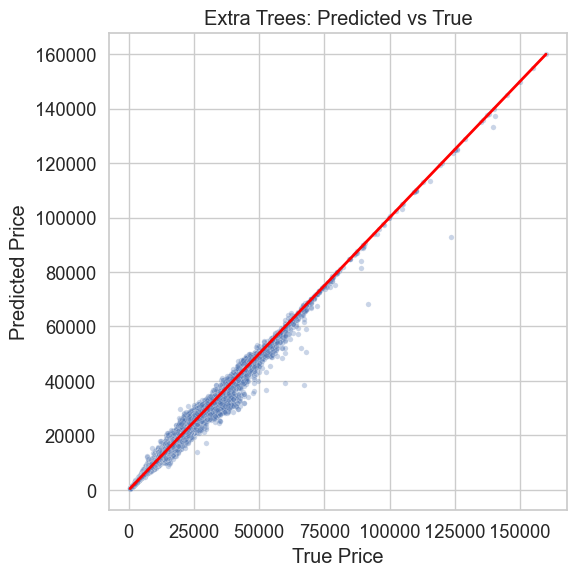

In [10]:
plot_pred_vs_true(et_final, "Extra Trees")

- The cloud of points is tightly concentrated around the "perfect predictions" line, indicating that the model captures the overall price pattern very well (even too well, as we've seen), with most predictions very close to the true values;
- At the very high-price range there are fewer points and a bit more spread, suggesting that the model is slightly less precise for very expensive cars, likely due to fewer observations.

#### 2.3.2. Residuals vs Predicted (heteroscedasticity check)

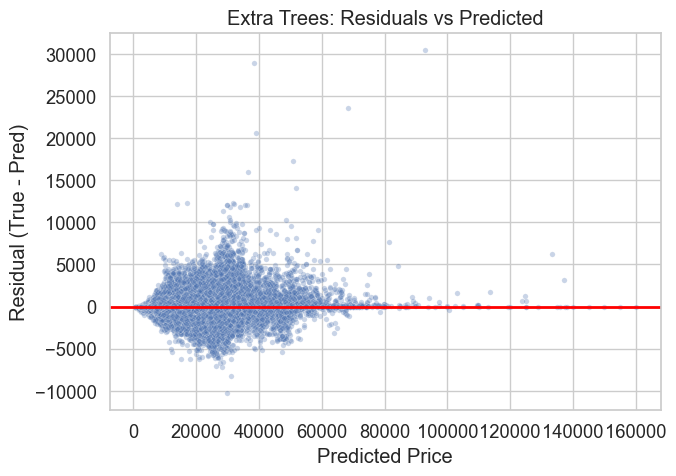

In [11]:
plot_residuals(et_final, "Extra Trees")

- Residuals are centered around 0 along almost all predicted price levels, indicating no strong systematic bias (the model is not consistently over or underestimating); 
- The spread of residuals is larger for mid-range predicted prices and shrinks for higher predicted prices, which may reflect data imbalance (many more mid-priced cars than very expensive ones);
- There are some moderate outliers (large positive and negative residuals), but they are relatively rare and do not show a clear structure, which is compatible with a reasonably well-specified model.

#### 2.3.3. Residual distribution

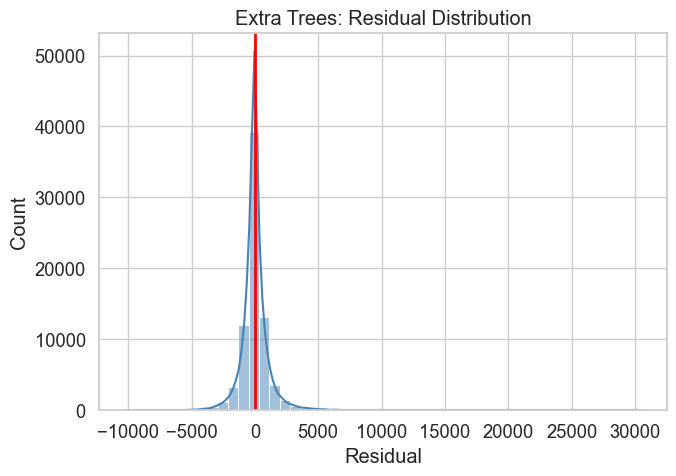

In [12]:
plot_residual_distribution(et_final, "Extra Trees")

- The residuals form a roughly symmetric, bell-shaped distribution centered at 0, which is consistent with an unbiased model;
- Most residuals are concentrated close to 0, with a high peak, suggesting that for most cars the absolute error is relatively small;
- However, the distribution has heavier tails, revealing a minority of cars where the prediction error is much larger; these likely correspond to more unusual combinations of features or noisy target values.

#### 2.3.4. Permutation Importance

/opt/anaconda3/envs/Fall2526/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_36681/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


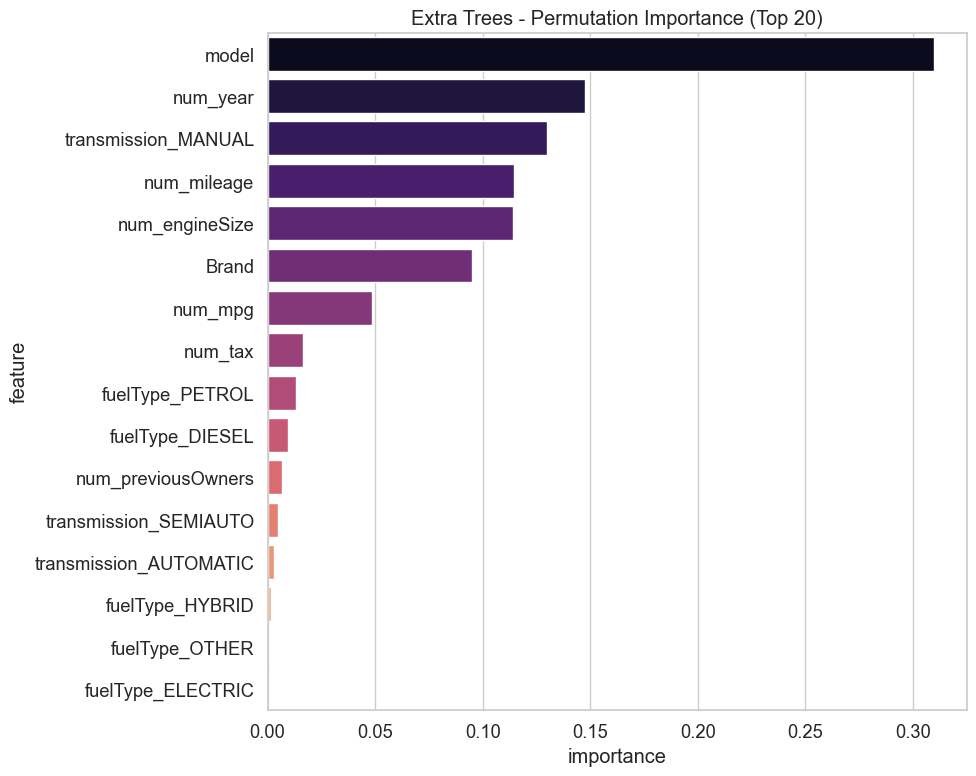

In [13]:
plot_permutation_importance(et_final, "Extra Trees")

#### 2.3.5. SHAP


SHAP for Extra Trees (sample size = 2000)


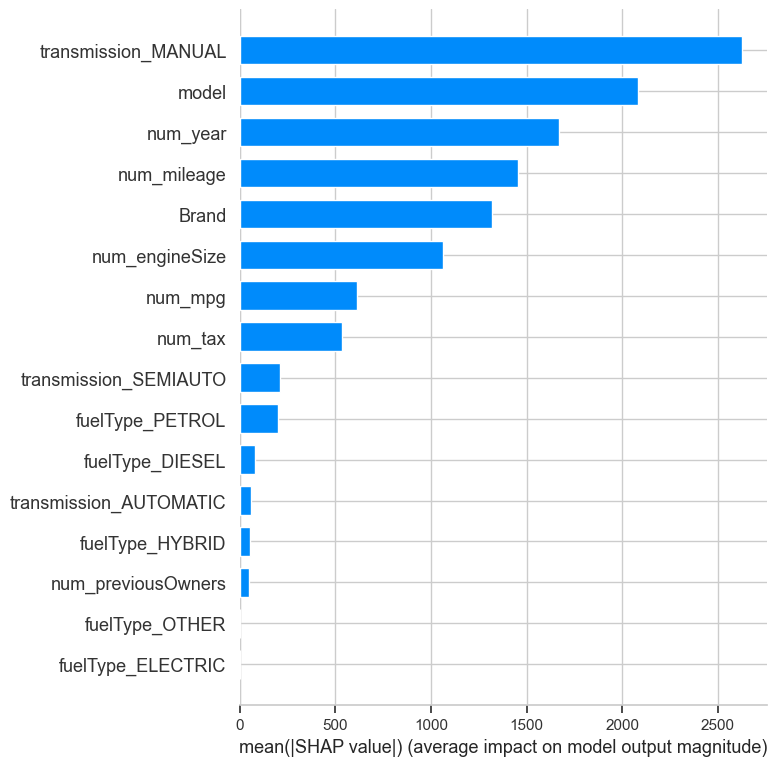

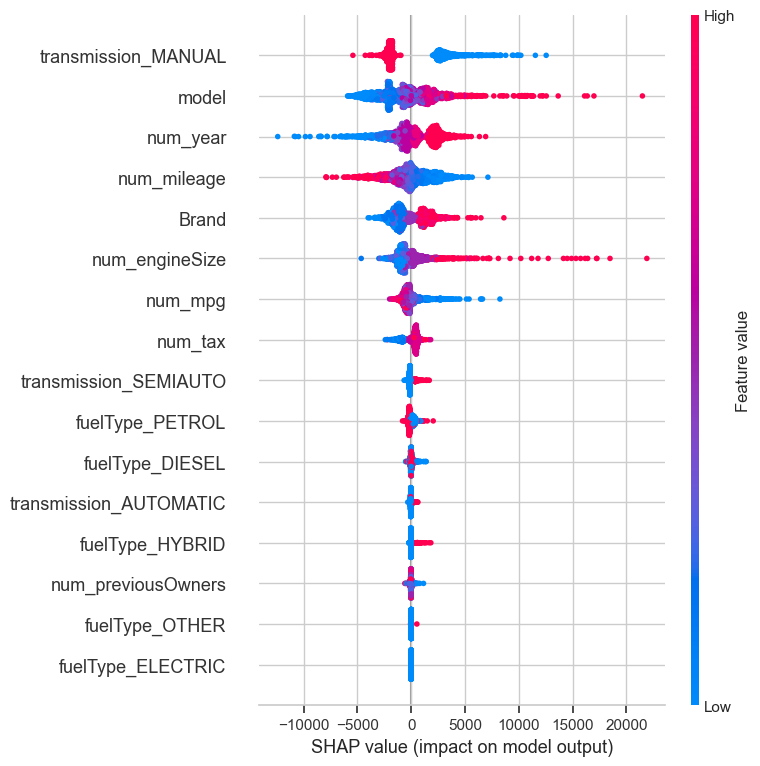

In [14]:
#X_shap = X_full_final.copy()
#X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(et_final, X_full_final, "Extra Trees") 

#### 2.3.6. Feature importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_48916/1213273110.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="viridis")


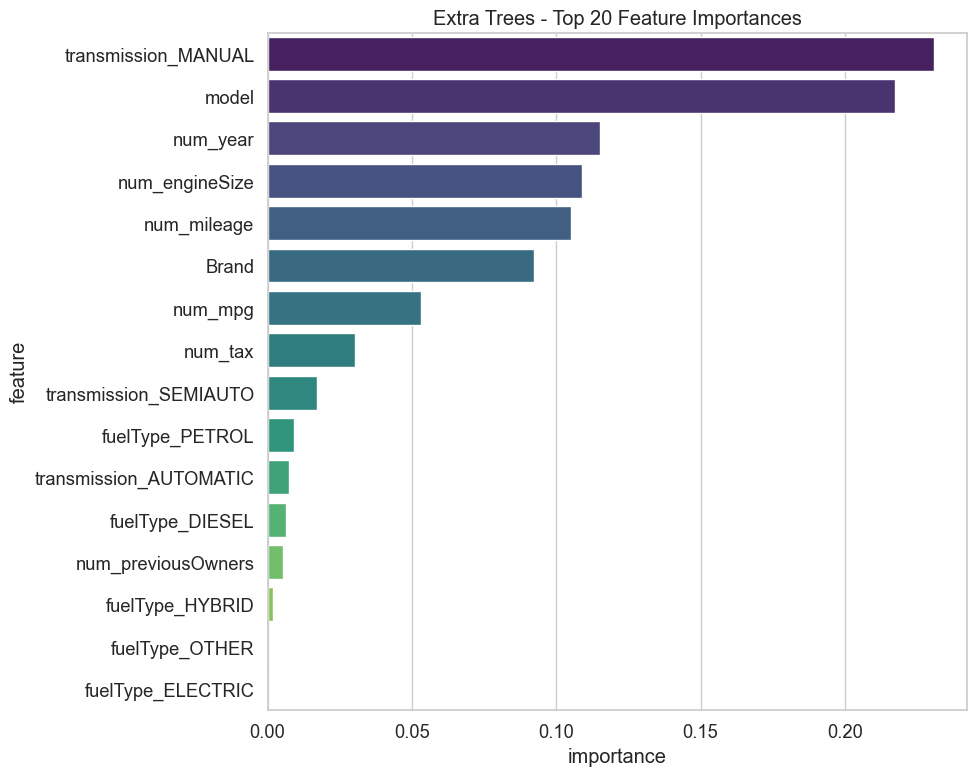

In [15]:
plot_feature_importance(et_final, "Extra Trees")

#### 2.3.7. Split frequency

In [16]:
compute_split_frequency(et_final)

,feature,split_count
5,num_mileage,10889292
7,num_previousOwners,5588939
8,num_mpg,4625126
6,num_tax,2901217
4,model,2699530
2,num_year,2617772
3,num_engineSize,1952669
0,Brand,1317974
13,transmission_AUTOMATIC,415050
9,transmission_SEMIAUTO,413192


### 2.4. Reduced Random Search Hyperparameter Search with K-Fold Cross-Validation

Because of the big overfit on et_final model, we decided to analyze a reduced hyperparameter space (removing the parameters that were most likely to produce overfitting results). In this section we present et_reduced_final.

In [3]:
# HYPERPARAMETERS RANDOM SEARCH SPACE
param_distributions = {
    "n_estimators": [800, 1000, 1200],          # number of trees
    "max_depth": [10, 15],                      # maximum depth of the tree 
    "min_samples_split": [4, 6],                # minimum samples to split an internal node
    "min_samples_leaf": [2, 3],                 # minimum samples at a leaf node
    "max_features": [0.3, 0.5],                 # number of features to consider at each split
    "bootstrap": [False],                       # ExtraTrees usually performs better without bootstrapping 
}
# We tested more hyperparameters before, but they had a big overfitting effect, even though the results on validation were better, 
# so we decided to develop another model keeping the hyperparameters that control overfitting the most.

N_RANDOM_CONFIGS = 48  # grid search

sampler = ParameterSampler(
    param_distributions,
    n_iter=N_RANDOM_CONFIGS,
    random_state=RANDOM_STATE
)

search_results = []

# Best RMSE
best_rmse = np.inf
best_config_rmse = None

# Best MAE
best_mae = np.inf
best_config_mae = None

# Best combined score (0.5 RMSE + 0.5 MAE)
best_combo = np.inf
best_config_combo = None

log_path = "et_reduced_random_search_log.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        """
        Keeps messages only on log file (keeping the notebook clean)
        """
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log("# =============================")
    log("# START OF RANDOM SEARCH ExtraTrees")
    log("# =============================")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")

    # RANDOM SEARCH + CV
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []
        fold_bias  = []

        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []
        fold_bias_train  = []

        # CV for this configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            # 1) SEPARATE TRAIN / VALIDATION
            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # NaNs before numeric imputation
            log(f"[C{config_id}|F{fold}] NaNs before numeric imputation (only num features):")
            log(str(X_train[numeric_features].isna().sum()))

            log(f"[C{config_id}|F{fold}] NaNs before (categoricals):")
            log(str(X_train[categorical_features].isna().sum()))

            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categoricals):")
            log(str(unknown_counts_before))

            # 2) NUMERICAL PRE PROCESSING (fit for train, transform for val)
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            tax_state = fit_tax_imputer(
                X_train,
                tax_col="tax",
                do_abs=True
            )
            X_train = transform_tax_imputer(X_train, state=tax_state)
            X_val   = transform_tax_imputer(X_val,   state=tax_state)

            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            '''paint_state = fit_paint_quality_imputer(
                X_train,
                paint_col="paintQuality%"
            )
            X_train = transform_paint_quality_imputer(X_train, state=paint_state)
            X_val   = transform_paint_quality_imputer(X_val,   state=paint_state)'''

            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            log(f"[C{config_id}|F{fold}] After numeric imputation: X_train shape = {X_train.shape}, X_val shape = {X_val.shape}")
            log(f"[C{config_id}|F{fold}] NaNs after numeric imputation (only num features):")
            log(str(X_train[numeric_features].isna().sum()))

            # CATEGORICALS
            # solve invalid / ambiguous brands 
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )

            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )

            log(f"[C{config_id}|F{fold}] After solving Brand:")
            log("  Nº still invalid brands (train): " + str(len(brand_still_invalid_train)))
            log("  Example of invalid brands (train): " + str(brand_still_invalid_train[:10]))

            # solve invalid / ambiguous models
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )

            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )

            log(f"[C{config_id}|F{fold}] After solving model:")
            log("  Nº still invalid models (train): " + str(len(model_still_invalid_train)))
            log("  Example of invalid models (train): " + str(model_still_invalid_train[:10]))

            # solve transmission
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )

            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )

            log(f"[C{config_id}|F{fold}] After solving transmission:")
            log("  Distinct values (train): " +
                str(sorted(X_train["transmission"].astype(str).str.upper().unique())))
            log("  Still problematic (train): " + str(transm_still_invalid_train[:10]))

            # solve fuelType
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )

            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )

            log(f"[C{config_id}|F{fold}] After solving fuelType:")
            log("  Distinct values (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Still problematic (train): " + str(fuel_still_invalid_train[:10]))

            # NUMERICAL AND CATEGORY SUMMARY
            log(f"[C{config_id}|F{fold}] --- NUMERICAL (train, after imputation) ---")
            num_means_train = X_train[numeric_features].mean()
            num_nans_train  = X_train[numeric_features].isna().sum()
            log("  Means (train):")
            log(str(num_means_train))
            log("  NaNs (train):")
            log(str(num_nans_train))

            num_means_val = X_val[numeric_features].mean()
            num_nans_val  = X_val[numeric_features].isna().sum()
            log("  Means (val):")
            log(str(num_means_val))
            log("  NaNs  (val):")
            log(str(num_nans_val))

            log(f"[C{config_id}|F{fold}] --- CATEGORICAL (train, after solving every problematic entry) ---")
            cat_nans_train     = X_train[categorical_features].isna().sum()
            cat_unknown_train  = (X_train[categorical_features] == "UNKNOWN").sum()
            log("  NaNs (train):")
            log(str(cat_nans_train))
            log("  'UNKNOWN' (train):")
            log(str(cat_unknown_train))

            log(f"[C{config_id}|F{fold}] Distinct values (train):")
            for col in categorical_features:
                uniques = sorted(X_train[col].dropna().astype(str).unique())
                if len(uniques) > 30:
                    shown = uniques[:30]
                    log(f"    {col}: {len(uniques)} distinct values. First 30: {shown} ...")
                else:
                    log(f"    {col}: {len(uniques)} distinct values: {uniques}")

            # 3) CATEGORICAL ENCODING
            high_card_features = ["Brand", "model"]  # target encoding
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            unknown_mask_train = (X_train[categorical_features] == "UNKNOWN")
            unknown_mask_val   = (X_val[categorical_features]   == "UNKNOWN")

            unknown_counts_train = unknown_mask_train.sum()
            unknown_counts_val   = unknown_mask_val.sum()

            rows_with_unknown_train = unknown_mask_train.any(axis=1).sum()
            rows_with_unknown_val   = unknown_mask_val.any(axis=1).sum()

            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after solving (categoricals, train):")
            log(str(unknown_counts_train))
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after solving (categoricals, val):")
            log(str(unknown_counts_val))
            log(f"[C{config_id}|F{fold}] Nº observations with >=1 UNKNOWN (train): {rows_with_unknown_train}")
            log(f"[C{config_id}|F{fold}] Nº observations with >=1 UNKNOWN (val)  : {rows_with_unknown_val}")

            # 3.1) Target Encoding for brand and model
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)

            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # 3.2) One-hot encoding for other categoricals
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])

            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            log(f"[C{config_id}|F{fold}] NaNs after encoding (X_train_cat, total): {X_train_cat.isna().sum().sum()}")
            log(f"[C{config_id}|F{fold}] NaNs after encoding (X_val_cat, total): {X_val_cat.isna().sum().sum()}")

            unknown_cols_train = [col for col in X_train_cat.columns if "UNKNOWN" in str(col)]
            unknown_cols_val   = [col for col in X_val_cat.columns if "UNKNOWN" in str(col)]

            log(f"[C{config_id}|F{fold}] Encoded columns with 'UNKNOWN' (train): {unknown_cols_train}")
            log(f"[C{config_id}|F{fold}] Encoded columns with 'UNKNOWN' (val)  : {unknown_cols_val}")

            # 4) NUMERIC SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features])
            X_val_num   = scaler.transform(X_val[numeric_features])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            log(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # 5) FINAL MATRIX (NUM + CAT)
            X_train_final = pd.concat(
                [X_train_num_df, X_train_cat],
                axis=1
            )
            X_val_final = pd.concat(
                [X_val_num_df, X_val_cat],
                axis=1
            )

            log(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # --------------------------------------------------------------------------------
            # 6) EXTRA TREES REGRESSOR 
            et_reduced = ExtraTreesRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params
            )

            log(f"[C{config_id}|F{fold}] Training ExtraTreesRegressor...")
            et_reduced.fit(X_train_final, y_train)
            
            log(f"[C{config_id}|F{fold}] Predicting...")

            y_pred_train = et_reduced.predict(X_train_final)
            y_pred_val   = et_reduced.predict(X_val_final)

            log(f"[C{config_id}|F{fold}] Predictions done.")

            # 7) FOLD METRICS (train and val)
            # VAL
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val))

            # TRAIN
            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)
            bias_tr = float(np.mean(y_pred_train - y_train))

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)
            fold_bias.append(bias_tr)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)
            fold_bias_train.append(bias_tr)

        # FOLDS MEAN FOR THIS CONFIGURATION
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)
        mean_bias_val = np.mean(fold_bias)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)
        mean_bias_tr = np.mean(fold_bias_train)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        # keep best RMSE (val)
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config_rmse = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} with average RMSE (VAL) = {best_rmse:.4f}")

        # keep best MAE (val)
        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} with average MAE (VAL) = {best_mae:.4f}")

        # keep best combined score
        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} with score = {best_combo:.4f}")

    log("")
    log("# =============================")
    log("# END OF RANDOM SEARCH ExtraTrees")
    log("# =============================")
    log(f"Best configuration (min RMSE VAL): {best_config_rmse}")
    log(f"Best average RMSE (VAL): {best_rmse:.4f}")
    log(f"Best configuration (min MAE VAL): {best_config_mae}")
    log(f"Best average MAE  (VAL): {best_mae:.4f}")
    log(f"Best configuration (combined score VAL): {best_config_combo}")
    log(f"Best combined score (VAL): {best_combo:.4f}")

# -----------------------------------------------------------------------------
# RANDOM SEARCH'S FINAL SUMMARY 
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="mae_mean", ascending=True)

display(results_df_sorted.head(10))

print("\nBest configuration found (min RMSE VAL):")
print(best_config_rmse)
print("Best average RMSE (VAL):", best_rmse)

print("\nBest configuration found (min MAE VAL):")
print(best_config_mae)
print("Best average MAE (VAL):", best_mae)

print("\nBest configuration found (min 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("Best combined score (VAL):", best_combo)

print(f"\nDetailed logs in: {log_path}")

# Save results in CSV
results_df_sorted.to_csv("et_reduced_random_search_results.csv", index=False)

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
36,37,800,4,2,0.5,15,False,2153.558791,1379.193663,0.951079,2531.673431,1542.796192,0.932266,2037.234812
37,38,1000,4,2,0.5,15,False,2154.046020,1379.327564,0.951057,2531.737735,1542.885004,0.932263,2037.311370
38,39,1200,4,2,0.5,15,False,2155.457753,1379.767374,0.950993,2533.465170,1543.327640,0.932170,2038.396405
39,40,800,6,2,0.5,15,False,2189.405061,1393.126024,0.949437,2541.864832,1546.028870,0.931720,2043.946851
40,41,1000,6,2,0.5,15,False,2190.326704,1394.068334,0.949394,2540.830920,1546.638812,0.931776,2043.734866
41,42,1200,6,2,0.5,15,False,2192.156315,1394.773430,0.949310,2542.339610,1546.988802,0.931695,2044.664206
43,44,1000,4,3,0.5,15,False,2275.908643,1429.275398,0.945363,2585.299795,1562.953412,0.929380,2074.126603
46,47,1000,6,3,0.5,15,False,2275.908643,1429.275398,0.945363,2585.299795,1562.953412,0.929380,2074.126603
45,46,800,6,3,0.5,15,False,2276.376623,1429.060761,0.945340,2586.599263,1563.123292,0.929309,2074.861277
42,43,800,4,3,0.5,15,False,2276.376623,1429.060761,0.945340,2586.599263,1563.123292,0.929309,2074.861277



Best configuration found (min RMSE VAL):
{'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': False}
Best average RMSE (VAL): 2531.6734310802244

Best configuration found (min MAE VAL):
{'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': False}
Best average MAE (VAL): 1542.7961921858935

Best configuration found (min 0.5*RMSE + 0.5*MAE):
{'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': False}
Best combined score (VAL): 2037.234811633059

Detailed logs in: et_reduced_random_search_log.txt


In this block we perform a random search over ExtraTreesRegressor hyperparameters using K-fold cross-validation (k=8), with all preprocessing done inside each fold to avoid data leakage.

Main steps:

1. **Cross-validation setup**  
   - We create an 8-fold K-fold object with shuffling and a fixed `random_state` to ensure reproducibility.
   - Each configuration will be evaluated across all 8 folds.

2. **Hyperparameter search space**  
   - We define a search space for:
     - `n_estimators` (number of trees),
     - `max_depth` (tree depth),
     - `min_samples_split` and `min_samples_leaf` (regularization via minimum samples),
     - `max_features` (proportion of features used at each split),
     - `bootstrap` and the tree split `criterion`.
   - We then sample a given number of random configurations (`N_RANDOM_CONFIGS`) from this space using `ParameterSampler`.

3. **Fold-level preprocessing (no leakage)**  
   For each configuration and each fold, we:
   - Split the data into `X_train`, `X_val`, `y_train`, `y_val`.
   - Apply the entire preprocessing pipeline **fit only on the training fold**:
     - Numeric imputations for `year`, `mileage`, `engineSize`, `tax`, `mpg`, `paintQuality%` and `previousOwners`;
     - Resolution of invalid or ambiguous categories for `Brand`, `model`, `transmission` and `fuelType`;
     - Target encoding for high-cardinality features (`Brand` and `model`);
     - One-hot encoding for the remaining categorical variables;
     - Scaling of all numeric variables with `StandardScaler`.
   - Concatenate the processed numeric and categorical features into a final design matrix for the model.

4. **Model training and evaluation per fold**  
   - For each fold we train an `ExtraTreesRegressor` instance with the current hyperparameters.
   - We compute performance metrics on both training and validation sets:
     - RMSE, MAE and R².
   - We log all intermediate checks (NaNs, UNKNOWN values, distinct categories, shapes) into a text file so we can verify that the preprocessing is stable.

5. **Aggregating results by configuration**  
   - For each configuration we average the RMSE, MAE and R² across folds.
   - We keep track of:
     - The configuration with the lowest validation RMSE;
     - The configuration with the lowest validation MAE;
     - The configuration with the best combined score (a weighted average of RMSE and MAE).
   - All results are stored in a DataFrame and saved to CSV for later analysis and reporting.

By the end of this cell we have a robust estimate of how different ExtraTrees configurations perform under cross-validation, and we select the best hyperparameters (in terms of RMSE) to train the final model on the full dataset.

### 2.5. Final Reduced Model Training and Kaggle Submission Generation

In [5]:
# FINAL CONFIGURATION
# Using the best configuration considering RMSE found in the cell above
final_config_et_reduced = best_config_rmse
#final_config_et_reduced = {'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': False}

print("Final config ExtraTrees used for train:", final_config_et_reduced)


# 1) PREPARE TRAIN FEATURES
X_full = X.copy()
y_full = y.copy()

# a) STRING NORMALIZATION (apply to train)
cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

for col in cols_to_normalize:
    if col in X_full.columns:
        # Using apply/lambda for safety with your custom function
        X_full[col] = X_full[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

# Define feature sets
high_card_features = ["Brand", "model"] 
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# 2) NUMERIC PRE PROCESSING - TRAIN (FIT & TRANSFORM)
# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

# Mileage
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

# Engine Size
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

# Tax
tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Paint Quality 
# paint_state = fit_paint_quality_imputer(X_full, paint_col="paintQuality%")
# X_full = transform_paint_quality_imputer(X_full, state=paint_state)

# Previous Owners
owners_state = fit_previous_owners_imputer(
    X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
)
X_full = transform_previous_owners_imputer(X_full, state=owners_state)


# 3) CATEGORICAL RESOLVERS - TRAIN (FIT & TRANSFORM)
# Brand
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands, 
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, brand_still_invalid_full = transform_ambiguous_brands(X_full, brand_state)
print(f"Train - Invalid Brands remaining: {len(brand_still_invalid_full)}")

# Model
model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year", 
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, model_still_invalid_full = transform_invalid_models(X_full, model_state)
print(f"Train - Invalid Models remaining: {len(model_still_invalid_full)}")

# Transmission
transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand", 
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

# Fuel Type
fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand", 
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)


# 4) CATEGORICAL ENCODING - TRAIN (FIT & TRANSFORM)
# Target Encoding
te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])

# One-Hot Encoding
ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)


# 5) NUMERIC SCALING - TRAIN (FIT & TRANSFORM)
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features])

X_full_num_df = pd.DataFrame(
    X_full_num,
    index=X_full.index,
    columns=[f"num_{col}" for col in numeric_features]
)


# 6) FINAL MATRIX - TRAIN
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)
print("X_full_final shape:", X_full_final.shape)


# 7) TRAIN MODEL
et_reduced_final = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config_et_reduced
)

print("Training final ExtraTrees model...")
et_reduced_final.fit(X_full_final, y_full)
print("Done.")


# 8) PREPARE TEST FEATURES
test_df = pd.read_csv("../../project_data/test.csv")

# a) STRING NORMALIZATION (apply to test)
# MUST be identical to train step
for col in cols_to_normalize:
    if col in test_df.columns:
        test_df[col] = test_df[col].apply(
            lambda x: basic_string_transformer(
                x, 
                remove_middle_spaces=True, 
                allow_extra_chars=""
            )
        )

X_test = test_df[numeric_features + categorical_features].copy()

# b) NUMERIC PREPROCESSING - TEST (TRANSFORM ONLY)
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
# X_test = transform_paint_quality_imputer(X_test, state=paint_state) 
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# c) CATEGORICAL RESOLVERS - TEST (TRANSFORM ONLY)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# d) ENCODING - TEST (TRANSFORM ONLY)
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# e) SCALING - TEST (TRANSFORM ONLY)
X_test_num = scaler.transform(X_test[numeric_features])
X_test_num_df = pd.DataFrame(
    X_test_num,
    index=X_test.index,
    columns=[f"num_{col}" for col in numeric_features]
)


# 9) FINAL MATRIX & PREDICTION
X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)

# ensure test columns are in the EXACT same order as train columns, preventing errors in case OneHotEncoder outputs columns in a different order
X_test_final = X_test_final[X_full_final.columns]

print("X_test_final shape:", X_test_final.shape)

y_test_pred = et_reduced_final.predict(X_test_final)

# Summary
print("Predictions summary:")
print(pd.Series(y_test_pred).describe())

# Prepare Submission
y_test_pred_round = np.round(y_test_pred).astype(int)

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred_round
})

# Dynamic filename generation (reflecting the parameters used)
p = final_config_et_reduced
sub_name = f"et_reduced_final_submission_n{p['n_estimators']}_d{p['max_depth']}_feat{p['max_features']}.csv"

submission.to_csv(sub_name, index=False)
print(f"Submission file created: {sub_name}")

Final config ExtraTrees used for train: {'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15, 'bootstrap': False}
Train - Invalid Brands remaining: 0
Train - Invalid Models remaining: 1
X_full_final shape: (75973, 16)
Training final ExtraTrees model...
Done.
X_test_final shape: (32567, 16)
Predictions summary:
count     32567.000000
mean      16908.754657
std        9013.685866
min        1808.381659
25%       10645.799147
50%       14755.368988
75%       21058.401910
max      135449.899798
dtype: float64
Submission file created: et_reduced_final_submission_n800_d15_feat0.5.csv


### 2.6. Visualizations

#### 2.6.1. Predicted vs true

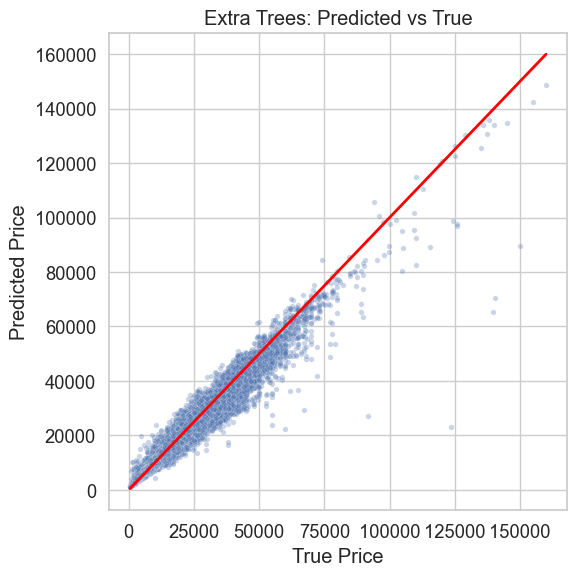

In [6]:
plot_pred_vs_true(et_reduced_final, "Extra Trees")

The majority of points fall near the diagonal, meaning **Extra Trees captures the general price trend well**.

There seems to be some underprediction at higher price levels (true prices above 75k). The spread widens as price increases, suggesting higher variance in predictions for expensive listings.

Overall, the model performs strongly but struggles slightly with the extreme upper end of the distribution.

#### 2.6.2. Residuals vs Predicted (heteroscedasticity check)

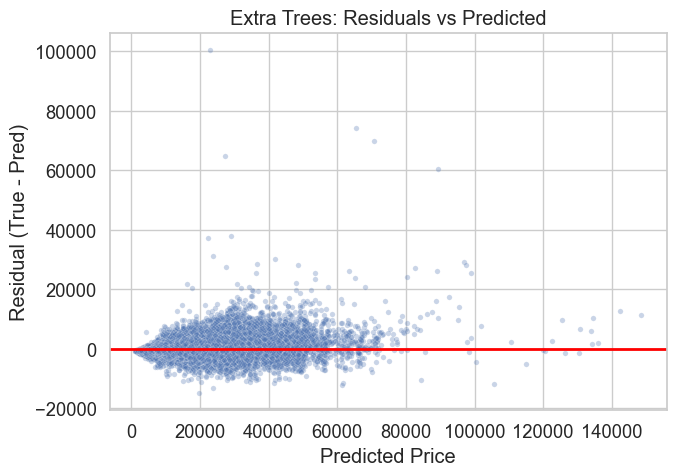

In [7]:
plot_residuals(et_reduced_final, "Extra Trees")

Residuals are mostly centered around 0, indicating predictions are not systematically biased.

The spread grows with larger predicted prices, consistent with the previous plot: higher-priced items show larger errors. There are some noticeable positive residual outliers, meaning the model occasionally underpredicts significantly for certain high-price cases.

No clear curved pattern is present, suggesting the model is not missing obvious nonlinear structure.

**Overall: residuals look healthy, with increasing noise at higher prices.**

#### 2.6.3. Residual distribution

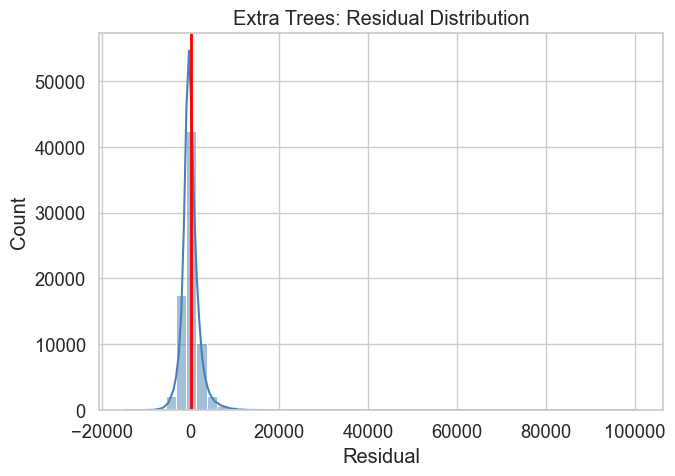

In [8]:
plot_residual_distribution(et_reduced_final, "Extra Trees")

The distribution is sharply peaked near 0, which is desirable.

The shape is slightly right-skewed, indicating more frequent underpredictions than overpredictions. Most residuals fall within a small range (clustered tightly), reinforcing that the model is generally accurate. A long right tail shows occasional large underpredictions, consistent with earlier plots.

#### 2.6.4. Permutation Importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_48916/2081930191.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="magma")


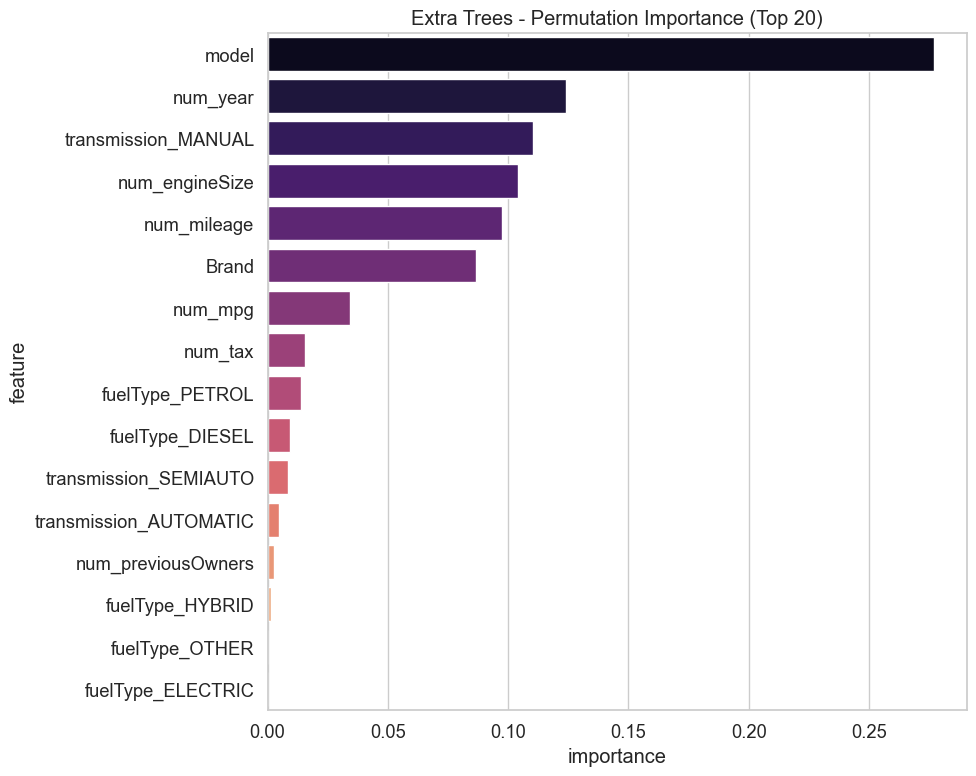

In [9]:
plot_permutation_importance(et_reduced_final, "Extra Trees")

The most important feature is `model`, followed by `num_year`, `transmission_MANUAL`, and `num_engineSize`. Features such as `fuelType_HYBRID`, `fuelType_OTHER`, and `fuelType_ELECTRIC` have much lower importance, suggesting they contribute less to the model's decision-making process.

In summary, this chart helps identify which variables have the greatest impact on the model's performance and which are relatively insignificant.

#### 2.6.5. SHAP


SHAP for Extra Trees (sample size = 2000)


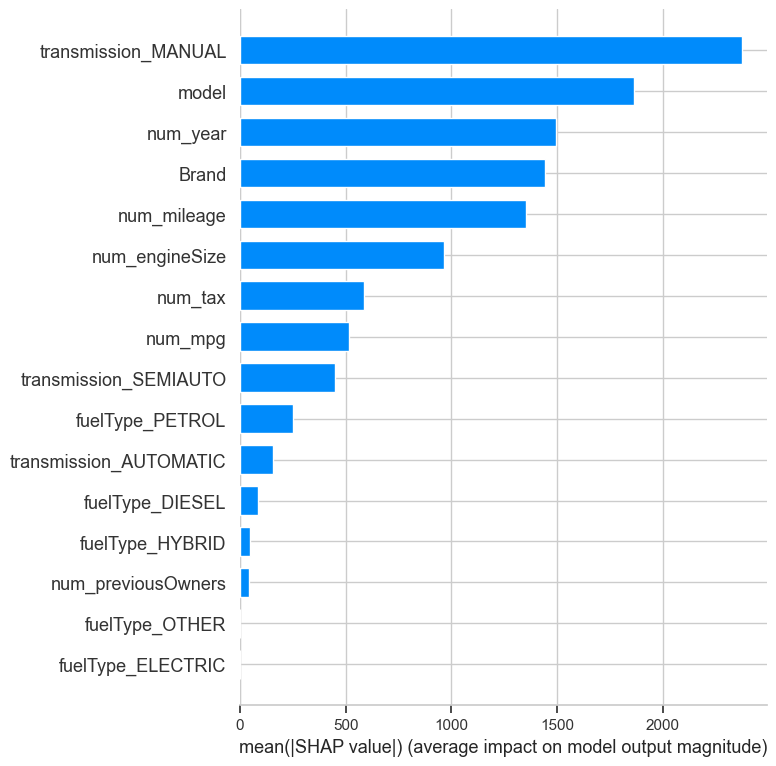

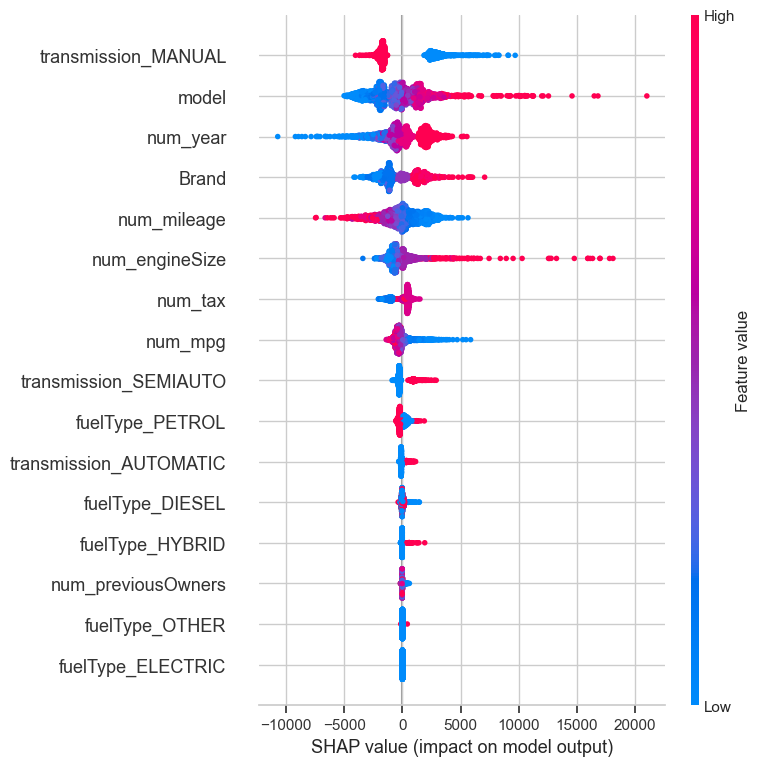

In [10]:
#X_shap = X_full_final.copy()
#X_shap = X_shap.astype(float)  # converts bool to 0/1 and ensures consistent dtype

apply_shap(et_reduced_final, X_full_final, "Extra Trees") 

- **Barplot:**
The `transmission_MANUAL` feature has the highest impact on model output magnitude, followed by `model`, `num_year`, and `Brand`. Features like `fuelType_ELECTRIC` and `fuelType_OTHER` show a relatively low average impact.<br>
This chart helps understand which features, on average, cause the largest shifts in model predictions. It complements the Permutation Importance chart by focusing on the average magnitude of impact rather than just the rank order of feature importance.

- **Beewarm:**
For `transmission_MANUAL`, we see that higher values (red) generally push the model output negatively (low SHAP value), while lower values (blue) tend to push the output positively. The spread of SHAP values for features like `fuelType_HYBRID`, `fuelType_OTHER`, and `fuelType_ELECTRIC` is much narrower, indicating these features have less variability in their impact on the model output.<br>
This plot provides a detailed view of the relationship between feature values and model output, allowing for insights into how specific feature values drive model predictions.

#### 2.6.6. Feature importance

/var/folders/ts/9fy52qg56jz05nxpdkmswkzw0000gr/T/ipykernel_48916/1213273110.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="viridis")


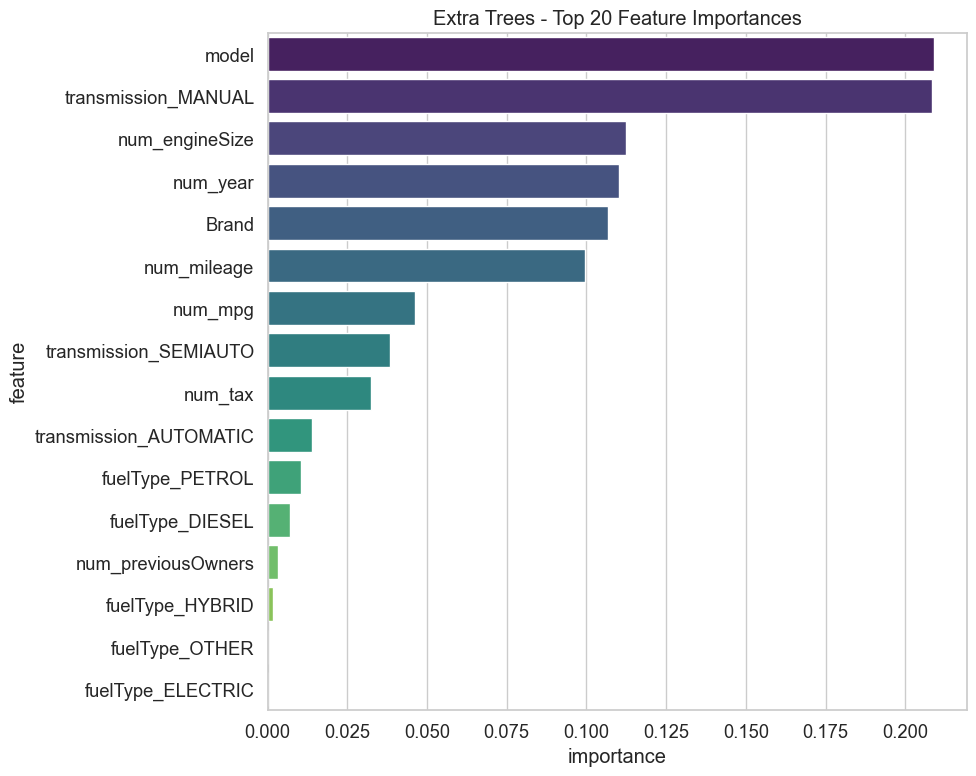

In [11]:
plot_feature_importance(et_reduced_final, "Extra Trees")

#### 2.6.7. Split frequency

In [12]:
compute_split_frequency(et_reduced_final)

,feature,split_count
10,num_mileage,638036
7,num_year,505643
4,model,473606
11,num_mpg,424286
8,num_previousOwners,398397
6,num_tax,308807
3,num_engineSize,296336
0,Brand,252535
2,fuelType_DIESEL,47926
14,fuelType_PETROL,46197


## 3. Model with Feature Selection

In [ ]:
from sklearn.feature_selection import SelectFromModel

# 0) SETTINGS
RANDOM_STATE = 42
N_SPLITS = 8

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

FS_KEEP_RATIO = 0.65
RF_FS_PARAMS = {
    "n_estimators":     500,
    "random_state":     RANDOM_STATE,
    "n_jobs":          -1,
    "max_depth":       None,
    "min_samples_split": 2,
    "min_samples_leaf":  2,
    "max_features":    "sqrt",
    "bootstrap":       True,
}

print(f"[ET FE+FS] FS_KEEP_RATIO = {FS_KEEP_RATIO}")
print(f"[ET FE+FS] RF_FS_PARAMS  = {RF_FS_PARAMS}")

# Old "good" ExtraTrees config (no FE/FS) – used just as a reference
final_config_et_old = {
    "n_estimators": 1200,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": 0.7,
    "max_depth": 20,
    "bootstrap": False,
}
print("[ET FE+FS] Old best config (baseline ET):", final_config_et_old)


# 1) LOAD TEST + IDS (dynamic path + id detection)
try:
    test_df_raw = pd.read_csv("test.csv")
except:
    try:
        test_df_raw = pd.read_csv("../project_data/test.csv")
    except:
        test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in test_df_raw.columns), None)

if ID_COL is not None:
    test_ids = test_df_raw[ID_COL].copy()
    test_df  = test_df_raw.drop(columns=[ID_COL]).copy()
else:
    test_ids = test_df_raw.index.copy()
    test_df  = test_df_raw.copy()

print(f"[ET FE+FS] Test raw shape: {test_df_raw.shape}, ID_COL = {ID_COL}")


# 2) BASE TRAIN DATA + TARGET
X_full = X.copy()
y_full = y.copy()
y_full_log = np.log1p(y_full)

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# 3) FEATURE ENGINEERING HELPERS (MATCH HGB SPECS)
def create_age_and_drop_year(df, year_col="year", base_year=2020, clip_future=True):
    df = df.copy()
    year = pd.to_numeric(df[year_col], errors="coerce")
    age = base_year - year
    if clip_future:
        age = age.clip(lower=0)
    df["age"] = age
    df = df.drop(columns=[year_col])
    return df

def add_owners_flagged(df, owners_col="previousOwners", new_col="owners_flagged",
                       drop_original=True, na_as_zero=True):
    df = df.copy()
    owners = pd.to_numeric(df[owners_col], errors="coerce")
    if na_as_zero:
        owners = owners.fillna(0)
    df[new_col] = (owners > 1).fillna(False).astype("int8")
    if drop_original and owners_col in df.columns:
        df = df.drop(columns=[owners_col])
    return df

def add_mileage_features(df, mileage_col="mileage", age_col="age",
                         drop_original=True, drop_ratio=True):
    df = df.copy()
    mileage = pd.to_numeric(df[mileage_col], errors="coerce")
    mileage = mileage.where(mileage >= 0, np.nan)

    df["log_mileage"] = np.log1p(mileage)

    age = pd.to_numeric(df[age_col], errors="coerce")
    age_safe = age.clip(lower=1)
    df["miles_per_year"]     = mileage / age_safe
    df["log_miles_per_year"] = np.log1p(df["miles_per_year"])

    if drop_ratio and "miles_per_year" in df.columns:
        df = df.drop(columns=["miles_per_year"])
    if drop_original and mileage_col in df.columns:
        df = df.drop(columns=[mileage_col])
    return df

def add_engine_bins(df, engine_col="engineSize", new_col="engine_bin", bins=None):
    df = df.copy()
    engine = pd.to_numeric(df[engine_col], errors="coerce")
    engine = engine.where(engine >= 0, np.nan)

    if bins is None:
        bins = [0, 1.0, 1.3, 1.6, 2.0, 2.5, 3.0, 4.0, np.inf]

    df[new_col] = pd.cut(engine, bins=bins, include_lowest=True, labels=False).astype("Int64")
    return df


# 4) STRING NORMALIZATION (TRAIN + TEST)
for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(
            X_full,
            column=col,
            remove_middle_spaces=True,
            allow_extra_chars=""
        )
    if col in test_df.columns:
        test_df[col] = fill_unknown(test_df[col])
        test_df = column_string_transformer(
            test_df,
            column=col,
            remove_middle_spaces=True,
            allow_extra_chars=""
        )

expected_cols = [c for c in (numeric_features + categorical_features) if c in X_full.columns]
X_full = X_full[expected_cols].copy()
X_test = test_df.reindex(columns=expected_cols, fill_value=np.nan).copy()

print(f"[ET FE+FS] X_full shape (raw schema): {X_full.shape}")
print(f"[ET FE+FS] X_test shape (raw schema): {X_test.shape}")


# 5) IMPUTATION + RESOLVERS (FIT ON TRAIN, TRANSFORM TRAIN+TEST)
print("[ET FE+FS] Fitting cleaning transforms on full train...")

# Year
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)
X_test = transform_year_with_model_median(X_test, state=year_state)

# Mileage (IMPORTANT to avoid NaNs in FE)
mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)

# Engine
engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)

# Tax with custom rules
X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")
X_test = transform_tax_custom_rules(X_test, "tax", "year", "fuelType", "engineSize")

# MPG
mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)

# Previous owners
owners_state = fit_previous_owners_imputer(X_full, "previousOwners", "year", "mileage")
X_full = transform_previous_owners_imputer(X_full, state=owners_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# Brand / model / transmission / fuel resolvers
brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

print("[ET FE+FS] Cleaning done.")


# 6) FEATURE ENGINEERING (TRAIN + TEST)
print("[ET FE+FS] Creating engineered features...")

X_full = add_owners_flagged(X_full, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
X_test = add_owners_flagged(X_test, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)

X_full = create_age_and_drop_year(X_full, year_col="year", base_year=2020)
X_test = create_age_and_drop_year(X_test, year_col="year", base_year=2020)

X_full = add_mileage_features(X_full, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
X_test = add_mileage_features(X_test, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

X_full = add_engine_bins(X_full, engine_col="engineSize", new_col="engine_bin")
X_test = add_engine_bins(X_test, engine_col="engineSize", new_col="engine_bin")

X_full["engine_bin"] = X_full["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
X_test["engine_bin"] = X_test["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

low_card_curr = low_card_features + ["engine_bin"]


# 7) ENCODING (TE for high-card, OHE for low-card) – LOG TARGET
print("[ET FE+FS] Encoding categoricals...")

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])
X_test_high = te.transform(X_test[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_curr])
X_full_low = ohe.transform(X_full[low_card_curr])
X_test_low = ohe.transform(X_test[low_card_curr])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
X_test_cat = pd.concat([X_test_high, X_test_low], axis=1)

drop_for_numeric = set(high_card_features + low_card_curr)
numeric_features_curr = [c for c in X_full.columns if c not in drop_for_numeric]

X_full_num = X_full[numeric_features_curr].copy()
X_test_num = X_test[numeric_features_curr].copy()

X_full_final = pd.concat([X_full_num, X_full_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

print(f"[ET FE+FS] Train matrix shape (pre-FS): {X_full_final.shape}")
print(f"[ET FE+FS] Test  matrix shape (pre-FS): {X_test_final.shape}")

# Sanity check: no NaNs
print("[ET FE+FS] NaNs in X_full_final:",
      X_full_final.isna().sum()[X_full_final.isna().sum() > 0])


# 8) FEATURE SELECTION VIA RF (FIT ON TRAIN, APPLY TO TRAIN+TEST)
print("[ET FE+FS] Fitting RF feature selector...")

n_feats = X_full_final.shape[1]
k = int(np.ceil(FS_KEEP_RATIO * n_feats))
k = max(1, min(k, n_feats))

rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
rf_fs.fit(X_full_final, y_full_log)

selector = SelectFromModel(
    estimator=rf_fs,
    threshold=-np.inf,
    max_features=k,
    prefit=True,
)

selected_cols = X_full_final.columns[selector.get_support()]
X_full_sel = X_full_final[selected_cols].copy()
X_test_sel = X_test_final.reindex(columns=selected_cols, fill_value=0).copy()

print(f"[ET FE+FS] Selected features: {len(selected_cols)}/{n_feats}")
print(f"[ET FE+FS] X_full_sel shape: {X_full_sel.shape}")
print(f"[ET FE+FS] X_test_sel shape: {X_test_sel.shape}")


# 9) RANDOM SEARCH FOR EXTRATREES ON FE+FS (LOG TARGET)
# small search space around old best config
et_param_distributions_fs = {
    "n_estimators": [800, 1000, 1200],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
    "max_features": [0.5, 0.7, "sqrt"],
    "bootstrap": [False],
}

N_RANDOM_CONFIGS_ET_FS = 25
log_path_et_fs = "et_fe_fs_random_search_log.txt"

sampler_et_fs = ParameterSampler(
    et_param_distributions_fs,
    n_iter=N_RANDOM_CONFIGS_ET_FS,
    random_state=RANDOM_STATE
)

et_fs_results = []

best_rmse = np.inf
best_rmse_config = None
best_mae = np.inf
best_mae_config = None
best_combo = np.inf
best_combo_config = None

with open(log_path_et_fs, "w", encoding="utf-8") as log_file:

    def log_et(msg: str):
        log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
        log_file.flush()

    log_et("# =======================================")
    log_et("# START OF RANDOM SEARCH ExtraTrees (FE+FS)")
    log_et("# =======================================")
    log_et(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS_ET_FS}")
    log_et(f"param_distributions = {et_param_distributions_fs}")

    for config_id, params in enumerate(sampler_et_fs, start=1):
        log_et("")
        log_et(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_ET_FS} ########")
        log_et(f"Parameters: {params}")

        fold_rmses_val = []
        fold_maes_val  = []
        fold_r2s_val   = []
        fold_bias_val  = []

        fold_rmses_tr = []
        fold_maes_tr  = []
        fold_r2s_tr   = []
        fold_bias_tr  = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_full_sel), start=1):
            log_et("")
            log_et(f"[CONFIG {config_id}] ==== FOLD {fold}/{N_SPLITS} ====")

            X_tr = X_full_sel.iloc[train_idx].copy()
            X_val = X_full_sel.iloc[val_idx].copy()

            y_tr_raw = y_full.iloc[train_idx].copy()
            y_val_raw = y_full.iloc[val_idx].copy()

            y_tr_log = y_full_log.iloc[train_idx].copy()

            et = ExtraTreesRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params
            )

            log_et(f"[C{config_id}|F{fold}] Training ExtraTrees (log-target, FE+FS)...")
            et.fit(X_tr, y_tr_log)

            y_pred_tr_log = et.predict(X_tr)
            y_pred_val_log = et.predict(X_val)

            y_pred_tr  = np.expm1(y_pred_tr_log)
            y_pred_val = np.expm1(y_pred_val_log)

            mse_val  = mean_squared_error(y_val_raw, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val_raw, y_pred_val)
            r2_val   = r2_score(y_val_raw, y_pred_val)
            bias_val = float(np.mean(y_pred_val - y_val_raw))

            mse_tr  = mean_squared_error(y_tr_raw, y_pred_tr)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_tr_raw, y_pred_tr)
            r2_tr   = r2_score(y_tr_raw, y_pred_tr)
            bias_tr = float(np.mean(y_pred_tr - y_tr_raw))

            log_et(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.2f} | MAE: {mae_tr:.2f} | "
                   f"R2: {r2_tr:.4f} | Bias(pred-true): {bias_tr:.2f}")
            log_et(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.2f} | MAE: {mae_val:.2f} | "
                   f"R2: {r2_val:.4f} | Bias(pred-true): {bias_val:.2f}")

            fold_rmses_tr.append(rmse_tr)
            fold_maes_tr.append(mae_tr)
            fold_r2s_tr.append(r2_tr)
            fold_bias_tr.append(bias_tr)

            fold_rmses_val.append(rmse_val)
            fold_maes_val.append(mae_val)
            fold_r2s_val.append(r2_val)
            fold_bias_val.append(bias_val)

        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)

        mean_rmse_tr = np.mean(fold_rmses_tr)
        mean_mae_tr  = np.mean(fold_maes_tr)
        mean_r2_tr   = np.mean(fold_r2s_tr)
        mean_bias_tr = np.mean(fold_bias_tr)

        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log_et("")
        log_et(f"Config {config_id} - Avg TRAIN RMSE: {mean_rmse_tr:.2f} | MAE: {mean_mae_tr:.2f} "
               f"| R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.2f}")
        log_et(f"Config {config_id} - Avg VAL   RMSE: {mean_rmse_val:.2f} | MAE: {mean_mae_val:.2f} "
               f"| R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.2f}")
        log_et(f"Config {config_id} - Combined score (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.2f}")

        et_fs_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean":  mean_mae_tr,
            "r2_train_mean":   mean_r2_tr,
            "bias_train_mean": mean_bias_tr,
            "rmse_mean":       mean_rmse_val,
            "mae_mean":        mean_mae_val,
            "r2_mean":         mean_r2_val,
            "bias_mean":       mean_bias_val,
            "combo_score":     combo_score,
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_rmse_config = {**params}
            log_et(f"[NEW BEST RMSE] Config {config_id} with avg RMSE (VAL) = {best_rmse:.4f}")

        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_mae_config = {**params}
            log_et(f"[NEW BEST MAE] Config {config_id} with avg MAE (VAL) = {best_mae:.4f}")

        if combo_score < best_combo:
            best_combo = combo_score
            best_combo_config = {**params}
            log_et(f"[NEW BEST COMBINED] Config {config_id} with score = {best_combo:.4f}")

    log_et("")
    log_et("# =======================================")
    log_et("# END OF RANDOM SEARCH ExtraTrees (FE+FS)")
    log_et("# =======================================")
    log_et(f"Best configuration (min RMSE VAL): {best_rmse_config}")
    log_et(f"Best average RMSE (VAL): {best_rmse:.4f}")
    log_et(f"Best configuration (min MAE VAL): {best_mae_config}")
    log_et(f"Best average MAE  (VAL): {best_mae:.4f}")
    log_et(f"Best configuration (combined score VAL): {best_combo_config}")
    log_et(f"Best combined score (VAL): {best_combo:.4f}")

et_fs_results_df = pd.DataFrame(et_fs_results)
et_fs_results_df_sorted = et_fs_results_df.sort_values(by="mae_mean", ascending=True)

display(et_fs_results_df_sorted.head(10))

print("\n[ET FE+FS] Best config by RMSE:", best_rmse_config, "RMSE:", best_rmse)
print("[ET FE+FS] Best config by MAE :", best_mae_config, "MAE :", best_mae)
print("[ET FE+FS] Best config by combo:", best_combo_config, "combo:", best_combo)

et_fs_results_df_sorted.to_csv("et_fe_fs_random_search_results.csv", index=False)
print(f"Detailed logs in: {log_path_et_fs}")

# Choose final config using combo criterion
final_config_et_fe_fs = best_rmse_config
print("\n[ET FE+FS] Final config used for training:", final_config_et_fe_fs)


# 10) TRAIN FINAL ET FE+FS MODEL + CREATE SUBMISSION
et_final_fe_fs = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config_et_fe_fs
)

print("\n[ET FE+FS] Training final ExtraTrees model (log-target) on full FE+FS matrix...")
et_final_fe_fs.fit(X_full_sel, y_full_log)
print("[ET FE+FS] Training done.")

print("[ET FE+FS] Predicting on test FE+FS matrix...")
pred_log_test = et_final_fe_fs.predict(X_test_sel)
pred_price_test = np.expm1(pred_log_test)
pred_price_test = np.maximum(pred_price_test, 0)

submission_et_fe_fs = pd.DataFrame({
    (ID_COL if ID_COL is not None else "id"): test_ids,
    "price": pred_price_test,
})

sub_name_et_fe_fs = (
    f"et_fe_fs_logtarget_submission_"
    f"n{final_config_et_fe_fs['n_estimators']}_"
    f"d{final_config_et_fe_fs['max_depth']}_"
    f"feat{final_config_et_fe_fs['max_features']}.csv"
)

submission_et_fe_fs.to_csv(sub_name_et_fe_fs, index=False)
print(f"[ET FE+FS] Submission file created: {sub_name_et_fe_fs}")
print(submission_et_fe_fs.head())

[ET FE+FS] FS_KEEP_RATIO = 0.65
[ET FE+FS] RF_FS_PARAMS  = {'n_estimators': 500, 'random_state': 42, 'n_jobs': -1, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}
[ET FE+FS] Old best config (baseline ET): {'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
[ET FE+FS] Test raw shape: (32567, 13), ID_COL = carID
[ET FE+FS] X_full shape (raw schema): (75973, 10)
[ET FE+FS] X_test shape (raw schema): (32567, 10)
[ET FE+FS] Fitting cleaning transforms on full train...
[ET FE+FS] Cleaning done.
[ET FE+FS] Creating engineered features...
[ET FE+FS] Encoding categoricals...
[ET FE+FS] Train matrix shape (pre-FS): (75973, 25)
[ET FE+FS] Test  matrix shape (pre-FS): (32567, 25)
[ET FE+FS] NaNs in X_full_final: Series([], dtype: int64)
[ET FE+FS] Fitting RF feature selector...
[ET FE+FS] Selected features: 17/25
[ET FE+FS] X_full_sel shape: (75973, 17)
[ET FE+FS

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,rmse_mean,mae_mean,r2_mean,bias_mean,combo_score
8,9,1200,4,2,0.7,30.0,False,1346.724113,768.241573,0.980861,-92.994978,2307.704690,1302.637254,0.943657,-150.810047,1805.170972
24,25,1000,4,2,0.7,NaN,False,1343.730609,765.191706,0.980946,-92.704633,2307.300026,1302.815575,0.943682,-150.299296,1805.057801
14,15,800,2,2,0.7,NaN,False,1343.832849,765.248014,0.980943,-92.703238,2307.411819,1303.084651,0.943677,-150.368563,1805.248235
0,1,1200,4,1,0.5,30.0,False,928.050704,530.370650,0.990912,-58.873858,2290.858584,1305.787974,0.944491,-140.868223,1798.323279
17,18,1000,4,1,0.5,30.0,False,928.164152,530.552225,0.990909,-58.894821,2291.439009,1306.032175,0.944461,-140.864915,1798.735592
2,3,1000,4,1,0.5,NaN,False,903.823226,508.316652,0.991379,-56.432445,2295.809587,1311.732093,0.944256,-139.833809,1803.770840
16,17,1200,2,2,0.7,20.0,False,1549.919742,925.509368,0.974654,-114.779738,2326.675225,1323.607244,0.942730,-166.140409,1825.141235
13,14,1200,2,2,0.5,30.0,False,1518.663921,873.796710,0.975667,-121.661464,2368.851955,1326.616830,0.940650,-176.874456,1847.734392
3,4,1200,4,2,0.5,30.0,False,1518.663921,873.796710,0.975667,-121.661464,2368.851955,1326.616830,0.940650,-176.874456,1847.734392
11,12,1000,2,2,0.5,30.0,False,1518.963537,874.037434,0.975657,-121.693348,2368.604836,1326.695091,0.940662,-176.874433,1847.649964



[ET FE+FS] Best config by RMSE: {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} RMSE: 2290.8585836358243
[ET FE+FS] Best config by MAE : {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 30, 'bootstrap': False} MAE : 1302.637254025009
[ET FE+FS] Best config by combo: {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} combo: 1798.3232789498238
Detailed logs in: et_fe_fs_random_search_log.txt

[ET FE+FS] Final config used for training: {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False}

[ET FE+FS] Training final ExtraTrees model (log-target) on full FE+FS matrix...
[ET FE+FS] Training done.
[ET FE+FS] Predicting on test FE+FS matrix...
[ET FE+FS] Submission file created: et_fe_fs_logtarget_submission_n12

------------

In this Extra Trees configuration, we isolate the contribution of `previousOwners` by removing the feature entirely from the pipeline. In practice, this means:
- `previousOwners` is not imputed, cleaned, or used as a predictor
- the model operates strictly on all remaining numerical and categorical features
- the preprocessing, encoders, resolvers and cross-validation loop remain identical to Model 1

The goal is to quantify whether `previousOwners` is actually useful or whether it introduces additional variance or noise.  
This model therefore serves as a controlled ablation study, keeping every other component unchanged while removing this single source of information.

In [4]:
# =========================================================
# EXTRA TREES MODEL 2 (NO previousOwners)
# SAME STRUCTURE AS FE+FS — WITH RANDOM SEARCH
# =========================================================

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from datetime import datetime

RANDOM_STATE = 42
N_SPLITS = 8

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("[ET M2] Running Extra Trees Model 2 (no previousOwners)")


# ---------------------------------------------------------
# 1) LOAD TEST + IDS
# ---------------------------------------------------------
try:
    test_df_raw = pd.read_csv("test.csv")
except:
    try:
        test_df_raw = pd.read_csv("../project_data/test.csv")
    except:
        test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in test_df_raw.columns), None)

test_ids = test_df_raw[ID_COL] if ID_COL else test_df_raw.index
test_df = test_df_raw.drop(columns=[ID_COL]) if ID_COL else test_df_raw.copy()

print(f"[ET M2] Test raw shape: {test_df_raw.shape}, ID_COL = {ID_COL}")


# ---------------------------------------------------------
# 2) BASE TRAIN DATA + TARGET
# ---------------------------------------------------------
X_full = X.copy()
y_full = y.copy()

# Remove previousOwners entirely
if "previousOwners" in X_full.columns:
    X_full = X_full.drop(columns=["previousOwners"])
if "previousOwners" in test_df.columns:
    test_df = test_df.drop(columns=["previousOwners"])

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# ---------------------------------------------------------
# 3) STRING NORMALIZATION
# ---------------------------------------------------------
for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(X_full, col, True, "")
    if col in test_df.columns:
        test_df[col] = fill_unknown(test_df[col])
        test_df = column_string_transformer(test_df, col, True, "")


# Build schema without previousOwners
expected_cols_m2 = [
    c for c in (numeric_features + categorical_features)
    if c != "previousOwners" and c in X_full.columns
]

X_full = X_full[expected_cols_m2].copy()
X_test = test_df.reindex(columns=expected_cols_m2, fill_value=np.nan).copy()

print(f"[ET M2] X_full shape (raw schema): {X_full.shape}")
print(f"[ET M2] X_test shape (raw schema): {X_test.shape}")


# ---------------------------------------------------------
# 4) IMPUTATION + RESOLVERS
# ---------------------------------------------------------
print("[ET M2] Applying imputers and categorical resolvers...")

year_state = fit_year_median(X_full, "year", "model")
X_full = transform_year_with_model_median(X_full, year_state)
X_test = transform_year_with_model_median(X_test, year_state)

mileage_state = fit_mileage_imputer(X_full, "mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, mileage_state)
X_test = transform_mileage_imputer(X_test, mileage_state)

engine_state = fit_engine_size_imputer(X_full, "engineSize")
X_full = transform_engine_size_imputer(X_full, engine_state)
X_test = transform_engine_size_imputer(X_test, engine_state)

tax_state = fit_tax_imputer(X_full, "tax", do_abs=True)
X_full = transform_tax_imputer(X_full, tax_state)
X_test = transform_tax_imputer(X_test, tax_state)

mpg_state = fit_mpg_imputer(X_full, "mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, mpg_state)
X_test = transform_mpg_imputer(X_test, mpg_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full,_,_ = transform_ambiguous_brands(X_full, brand_state)
X_test,_,_ = transform_ambiguous_brands(X_test, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full,_,_ = transform_invalid_models(X_full, model_state)
X_test,_,_ = transform_invalid_models(X_test, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full,_,_ = transform_transmission_resolver(X_full, transm_state)
X_test,_,_ = transform_transmission_resolver(X_test, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full,_,_ = transform_fueltype_resolver(X_full, fuel_state)
X_test,_,_ = transform_fueltype_resolver(X_test, fuel_state)

print("[ET M2] Cleaning complete.")


# ---------------------------------------------------------
# 5) NO FEATURE ENGINEERING FOR MODEL 2
# ---------------------------------------------------------
# keep original "year", do NOT create age


# ---------------------------------------------------------
# 6) ENCODING (TE + OHE)
# ---------------------------------------------------------
print("[ET M2] Encoding categoricals...")

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])
X_test_high = te.transform(X_test[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])
X_test_low = ohe.transform(X_test[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
X_test_cat = pd.concat([X_test_high, X_test_low], axis=1)

drop_for_numeric = set(high_card_features + low_card_features)
numeric_features_m2 = [c for c in X_full.columns if c not in drop_for_numeric]


# ---------------------------------------------------------
# 7) SCALE NUMERICAL FEATURES
# ---------------------------------------------------------
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features_m2])
X_test_num = scaler.transform(X_test[numeric_features_m2])

X_full_num = pd.DataFrame(X_full_num, index=X_full.index,
                          columns=[f"num_{c}" for c in numeric_features_m2])
X_test_num = pd.DataFrame(X_test_num, index=X_test.index,
                          columns=[f"num_{c}" for c in numeric_features_m2])


# ---------------------------------------------------------
# 8) FINAL MATRIX
# ---------------------------------------------------------
X_full_final = pd.concat([X_full_num, X_full_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

# Align columns
X_test_final = X_test_final[X_full_final.columns]

print("[ET M2] Final matrices shapes:")
print("  Train:", X_full_final.shape)
print("  Test :", X_test_final.shape)


# ---------------------------------------------------------
# 9) RANDOM SEARCH (OPTION A)
# ---------------------------------------------------------
et_param_distributions_m2 = {
    "n_estimators":     [800, 1000, 1200],
    "max_depth":        [None, 20, 30],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
    "max_features":     [0.5, 0.7, "sqrt"],
    "bootstrap":        [False],
}

N_RANDOM_CONFIGS_M2 = 25
sampler_m2 = ParameterSampler(
    et_param_distributions_m2,
    n_iter=N_RANDOM_CONFIGS_M2,
    random_state=RANDOM_STATE
)

best_rmse = np.inf
best_mae = np.inf
best_combo = np.inf

best_rmse_config = None
best_mae_config = None
best_combo_config = None

for config_id, params in enumerate(sampler_m2, start=1):

    fold_rmses = []
    fold_maes  = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full_final), start=1):

        X_tr = X_full_final.iloc[tr_idx]
        y_tr = y_full.iloc[tr_idx]
        X_va = X_full_final.iloc[va_idx]
        y_va = y_full.iloc[va_idx]

        model = ExtraTreesRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params
        )

        model.fit(X_tr, y_tr)
        pred_va = model.predict(X_va)

        rmse_va = np.sqrt(mean_squared_error(y_va, pred_va))
        mae_va  = mean_absolute_error(y_va, pred_va)

        fold_rmses.append(rmse_va)
        fold_maes.append(mae_va)

    mean_rmse = np.mean(fold_rmses)
    mean_mae  = np.mean(fold_maes)
    combo     = 0.5 * mean_rmse + 0.5 * mean_mae

    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_rmse_config = params

    if mean_mae < best_mae:
        best_mae = mean_mae
        best_mae_config = params

    if combo < best_combo:
        best_combo = combo
        best_combo_config = params

print("\n[ET M2] Best configs:")
print("  RMSE:", best_rmse_config, "->", best_rmse)
print("  MAE :", best_mae_config,  "->", best_mae)
print("  COMBO:", best_combo_config, "->", best_combo)

final_config_m2 = best_combo_config


# ---------------------------------------------------------
# 10) TRAIN FINAL MODEL
# ---------------------------------------------------------
print("\n[ET M2] Training final model with best config...")
et_final_m2 = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config_m2
)

et_final_m2.fit(X_full_final, y_full)
print("[ET M2] Final training completed.")


# ---------------------------------------------------------
# 11) PREDICT + SUBMISSION
# ---------------------------------------------------------
pred_test_m2 = et_final_m2.predict(X_test_final)
pred_test_m2 = np.round(pred_test_m2).astype(int)

submission_m2 = pd.DataFrame({
    ID_COL if ID_COL else "id": test_ids,
    "price": pred_test_m2
})

sub_name_m2 = (
    f"et_model2_n{final_config_m2['n_estimators']}"
    f"_d{final_config_m2['max_depth']}"
    f"_mf{final_config_m2['max_features']}.csv"
)

submission_m2.to_csv(sub_name_m2, index=False)
print("[ET M2] Submission saved as:", sub_name_m2)

submission_m2.head()


[ET M2] Running Extra Trees Model 2 (no previousOwners)
[ET M2] Test raw shape: (32567, 13), ID_COL = carID
[ET M2] X_full shape (raw schema): (75973, 9)
[ET M2] X_test shape (raw schema): (32567, 9)
[ET M2] Applying imputers and categorical resolvers...
[ET M2] Cleaning complete.
[ET M2] Encoding categoricals...
[ET M2] Final matrices shapes:
  Train: (75973, 15)
  Test : (32567, 15)

[ET M2] Best configs:
  RMSE: {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} -> 2173.5633168784752
  MAE : {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} -> 1266.4568162047362
  COMBO: {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} -> 1720.0100665416057

[ET M2] Training final model with best config...
[ET M2] Final training completed.
[ET M2] Submission saved as: e

,carID,price
0,89856,12984
1,106581,21869
2,80886,13723
3,100174,16496
4,81376,23801


---------

In [5]:
# =========================================================
# EXTRA TREES MODEL 3 (NO previousOwners + YEAR→AGE)
# SAME STRUCTURE AS FE+FS — WITH RANDOM SEARCH
# =========================================================

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
from datetime import datetime

RANDOM_STATE = 42
N_SPLITS = 8

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("[ET M3] Running Extra Trees Model 3 (no previousOwners + age conversion)")

# ---------------------------------------------------------
# 1) LOAD TEST + IDS
# ---------------------------------------------------------
try:
    test_df_raw = pd.read_csv("test.csv")
except:
    try:
        test_df_raw = pd.read_csv("../project_data/test.csv")
    except:
        test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in test_df_raw.columns), None)

test_ids = test_df_raw[ID_COL] if ID_COL else test_df_raw.index
test_df = test_df_raw.drop(columns=[ID_COL]) if ID_COL else test_df_raw.copy()

print(f"[ET M3] Test raw shape: {test_df_raw.shape}, ID_COL = {ID_COL}")


# ---------------------------------------------------------
# 2) BASE TRAIN DATA + TARGET
# ---------------------------------------------------------
X_full = X.copy()
y_full = y.copy()

# Remove previousOwners completely
if "previousOwners" in X_full.columns:
    X_full = X_full.drop(columns=["previousOwners"])
if "previousOwners" in test_df.columns:
    test_df = test_df.drop(columns=["previousOwners"])

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features]


# ---------------------------------------------------------
# 3) STRING NORMALIZATION
# ---------------------------------------------------------
for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(X_full, col, True, "")
    if col in test_df.columns:
        test_df[col] = fill_unknown(test_df[col])
        test_df = column_string_transformer(test_df, col, True, "")

expected_cols_m3 = [
    c for c in (numeric_features + categorical_features)
    if c != "previousOwners" and c in X_full.columns
]

X_full = X_full[expected_cols_m3].copy()
X_test = test_df.reindex(columns=expected_cols_m3, fill_value=np.nan).copy()


# ---------------------------------------------------------
# 4) IMPUTATION + RESOLVERS (FIT ON TRAIN, APPLY TO TEST)
# ---------------------------------------------------------
print("[ET M3] Applying imputers and categorical resolvers...")

year_state = fit_year_median(X_full, "year", "model")
X_full = transform_year_with_model_median(X_full, year_state)
X_test = transform_year_with_model_median(X_test, year_state)

mileage_state = fit_mileage_imputer(X_full, "mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, mileage_state)
X_test = transform_mileage_imputer(X_test, mileage_state)

engine_state = fit_engine_size_imputer(X_full, "engineSize")
X_full = transform_engine_size_imputer(X_full, engine_state)
X_test = transform_engine_size_imputer(X_test, engine_state)

tax_state = fit_tax_imputer(X_full, "tax", do_abs=True)
X_full = transform_tax_imputer(X_full, tax_state)
X_test = transform_tax_imputer(X_test, tax_state)

mpg_state = fit_mpg_imputer(X_full, "mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, mpg_state)
X_test = transform_mpg_imputer(X_test, mpg_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full,_,_ = transform_ambiguous_brands(X_full, brand_state)
X_test,_,_ = transform_ambiguous_brands(X_test, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full,_,_ = transform_invalid_models(X_full, model_state)
X_test,_,_ = transform_invalid_models(X_test, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full,_,_ = transform_transmission_resolver(X_full, transm_state)
X_test,_,_ = transform_transmission_resolver(X_test, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full,_,_ = transform_fueltype_resolver(X_full, fuel_state)
X_test,_,_ = transform_fueltype_resolver(X_test, fuel_state)


# ---------------------------------------------------------
# 5) FEATURE ENGINEERING FOR MODEL 3 → ONLY AGE
# ---------------------------------------------------------
print("[ET M3] Converting year → age...")

X_full = create_age_and_drop_year(X_full, "year", base_year=2020)
X_test = create_age_and_drop_year(X_test, "year", base_year=2020)

# No other FE (no owners_flagged, no mileage FE, no engine bins)


# ---------------------------------------------------------
# 6) ENCODING (TE + OHE)
# ---------------------------------------------------------
print("[ET M3] Encoding categoricals...")

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)
X_full_high = te.transform(X_full[high_card_features])
X_test_high = te.transform(X_test[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])
X_test_low = ohe.transform(X_test[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)
X_test_cat = pd.concat([X_test_high, X_test_low], axis=1)

drop_for_numeric = set(high_card_features + low_card_features)
numeric_features_m3 = [c for c in X_full.columns if c not in drop_for_numeric]


# ---------------------------------------------------------
# 7) SCALING NUMERICAL FEATURES
# ---------------------------------------------------------
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_features_m3])
X_test_num = scaler.transform(X_test[numeric_features_m3])

X_full_num = pd.DataFrame(X_full_num, index=X_full.index,
                          columns=[f"num_{c}" for c in numeric_features_m3])
X_test_num = pd.DataFrame(X_test_num, index=X_test.index,
                          columns=[f"num_{c}" for c in numeric_features_m3])


# ---------------------------------------------------------
# 8) FINAL MATRIX
# ---------------------------------------------------------
X_full_final = pd.concat([X_full_num, X_full_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

X_test_final = X_test_final[X_full_final.columns]

print("[ET M3] Final matrices shapes:")
print("  Train:", X_full_final.shape)
print("  Test :", X_test_final.shape)


# ---------------------------------------------------------
# 9) RANDOM SEARCH (OPTION A — SAME SPACE AS FE+FS)
# ---------------------------------------------------------
et_param_distributions_m3 = {
    "n_estimators":     [800, 1000, 1200],
    "max_depth":        [None, 20, 30],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
    "max_features":     [0.5, 0.7, "sqrt"],
    "bootstrap":        [False],
}

N_RANDOM_CONFIGS_M3 = 25

sampler_m3 = ParameterSampler(
    et_param_distributions_m3,
    n_iter=N_RANDOM_CONFIGS_M3,
    random_state=RANDOM_STATE
)

best_rmse = np.inf
best_mae = np.inf
best_combo = np.inf

best_rmse_config = None
best_mae_config = None
best_combo_config = None

for config_id, params in enumerate(sampler_m3, start=1):

    fold_rmses = []
    fold_maes  = []
    fold_r2s   = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_full_final), start=1):

        X_tr = X_full_final.iloc[tr_idx]
        y_tr = y_full.iloc[tr_idx]
        X_va = X_full_final.iloc[va_idx]
        y_va = y_full.iloc[va_idx]

        model = ExtraTreesRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params
        )

        model.fit(X_tr, y_tr)
        pred_va = model.predict(X_va)

        rmse_va = np.sqrt(mean_squared_error(y_va, pred_va))
        mae_va  = mean_absolute_error(y_va, pred_va)

        fold_rmses.append(rmse_va)
        fold_maes.append(mae_va)

    mean_rmse = np.mean(fold_rmses)
    mean_mae  = np.mean(fold_maes)
    combo     = 0.5 * mean_rmse + 0.5 * mean_mae

    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_rmse_config = params

    if mean_mae < best_mae:
        best_mae = mean_mae
        best_mae_config = params

    if combo < best_combo:
        best_combo = combo
        best_combo_config = params

print("\n[ET M3] Best configs:")
print("RMSE   :", best_rmse_config, "->", best_rmse)
print("MAE    :", best_mae_config,  "->", best_mae)
print("COMBO  :", best_combo_config, "->", best_combo)

final_config_m3 = best_combo_config


# ---------------------------------------------------------
# 10) FINAL TRAIN WITH BEST CONFIG
# ---------------------------------------------------------
print("\n[ET M3] Training FINAL model...")
et_final_m3 = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config_m3
)

et_final_m3.fit(X_full_final, y_full)
print("[ET M3] Final training completed.")


# ---------------------------------------------------------
# 11) PREDICT + SUBMISSION
# ---------------------------------------------------------
pred_test_m3 = et_final_m3.predict(X_test_final)
pred_test_m3 = np.round(pred_test_m3).astype(int)

submission_m3 = pd.DataFrame({
    ID_COL if ID_COL else "id": test_ids,
    "price": pred_test_m3
})

sub_name_m3 = (
    f"et_model3_age_n{final_config_m3['n_estimators']}"
    f"_d{final_config_m3['max_depth']}"
    f"_mf{final_config_m3['max_features']}.csv"
)

submission_m3.to_csv(sub_name_m3, index=False)
print("[ET M3] Submission saved as:", sub_name_m3)

submission_m3.head()

[ET M3] Running Extra Trees Model 3 (no previousOwners + age conversion)
[ET M3] Test raw shape: (32567, 13), ID_COL = carID
[ET M3] Applying imputers and categorical resolvers...
[ET M3] Converting year → age...
[ET M3] Encoding categoricals...
[ET M3] Final matrices shapes:
  Train: (75973, 15)
  Test : (32567, 15)

[ET M3] Best configs:
RMSE   : {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} -> 2173.796400869956
MAE    : {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} -> 1266.3382944020632
COMBO  : {'n_estimators': 1200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False} -> 1720.0673476360096

[ET M3] Training FINAL model...
[ET M3] Final training completed.
[ET M3] Submission saved as: et_model3_age_n1200_d30_mf0.5.csv


,carID,price
0,89856,12541
1,106581,21914
2,80886,13807
3,100174,16498
4,81376,23794


## ExtraTrees variants

Config + shared utilities

In [ ]:
import numpy as np
import pandas as pd
import os, random, logging
from datetime import datetime

from sklearn.model_selection import KFold, ParameterSampler
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


# Global configs
valid_transmissions = ["MANUAL", "AUTOMATIC", "SEMIAUTO"]
valid_fueltypes    = ["PETROL", "DIESEL", "HYBRID"]

N_SPLITS = 8
RANDOM_STATE = 42

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


# Smaller random search space 
et_param_distributions_small = {
    "n_estimators":      [600, 800, 1000],
    "max_depth":         [None, 20, 30],
    "min_samples_split": [2, 4],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", 0.5, 0.7],
    "bootstrap":         [False],
}

N_RANDOM_CONFIGS_ET = 20  # reduced because of computation time

sampler = ParameterSampler(
    et_param_distributions_small,
    n_iter=N_RANDOM_CONFIGS_ET,
    random_state=RANDOM_STATE
)


# Feature Selection base model 
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def _rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _bias_pred_minus_true(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))

def _safe_log1p(y):
    return np.log1p(np.asarray(y, dtype=float))

def _safe_expm1(y):
    return np.expm1(np.asarray(y, dtype=float))

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]

def _normalize_strings(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: basic_string_transformer(
                    x,
                    remove_middle_spaces=True,
                    allow_extra_chars=""
                )
            )
    return df

Random search runner for 5 variants

In [4]:
# =========================================================
# 5 VARIANTS (ExtraTrees) — SAME LOGIC AS ElasticNet
# =========================================================

VARIANTS = [
    {
        "name": "et_v1_original_price_no_fe_fs",
        "desc": "Original features, no FE/FS, target=price",
        "drop_prev_owners": False,
        "use_age_instead_of_year": False,
        "use_log_target": False,
        "do_feature_engineering": False,
        "do_feature_selection": False,
        "fs_keep_ratio": None,
    },
    {
        "name": "et_v2_dropOwners_logTarget",
        "desc": "Drop previousOwners, target=log1p(price)",
        "drop_prev_owners": True,
        "use_age_instead_of_year": False,
        "use_log_target": True,
        "do_feature_engineering": False,
        "do_feature_selection": False,
        "fs_keep_ratio": None,
    },
    {
        "name": "et_v3_dropOwners_logTarget_age",
        "desc": "Variant 2 + replace year with age",
        "drop_prev_owners": True,
        "use_age_instead_of_year": True,
        "use_log_target": True,
        "do_feature_engineering": False,
        "do_feature_selection": False,
        "fs_keep_ratio": None,
    },
    {
        "name": "et_v4_dropOwners_logTarget_age_fs80",
        "desc": "Variant 3 + FS keep 80%",
        "drop_prev_owners": True,
        "use_age_instead_of_year": True,
        "use_log_target": True,
        "do_feature_engineering": False,
        "do_feature_selection": True,
        "fs_keep_ratio": 0.80,
    },
    {
        "name": "et_v5_dropOwners_logTarget_age_fs65_fullFE",
        "desc": "Variant 3 + FS keep 65% + all FE features",
        "drop_prev_owners": True,
        "use_age_instead_of_year": True,
        "use_log_target": True,
        "do_feature_engineering": True,   # owners_flagged, mileage feats, engine_bin
        "do_feature_selection": True,
        "fs_keep_ratio": 0.65,
    },
]


def run_et_variant_random_search(variant: dict):
    variant_name = variant["name"]
    log_path = f"{variant_name}_search_log.txt"
    out_csv  = f"{variant_name}_search_results.csv"

    search_results = []
    best_rmse = np.inf
    best_config = None

    with open(log_path, "w", encoding="utf-8") as log_file:
        def log(msg: str):
            log_file.write(datetime.now().strftime("[%Y-%m-%d %H:%M:%S] ") + msg + "\n")
            log_file.flush()

        log("# =======================================")
        log(f"# START ExtraTrees RANDOM SEARCH | {variant_name}")
        log(f"# {variant['desc']}")
        log("# =======================================")
        log(f"N_SPLITS={N_SPLITS} | N_CONFIGS={N_RANDOM_CONFIGS_ET}")
        log(f"param_space={et_param_distributions_small}")

        for config_id, params in enumerate(sampler, start=1):
            log("")
            log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS_ET} ########")
            log(f"Parameters: {params}")

            fold_rows = []

            for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
                log(f"\n[C{config_id}|F{fold}] fold start")

                X_train = X.iloc[train_idx].copy()
                X_val   = X.iloc[val_idx].copy()
                y_train = y.iloc[train_idx].copy()
                y_val   = y.iloc[val_idx].copy()

                # -------------------------------------------------
                # Target handling
                # -------------------------------------------------
                if variant["use_log_target"]:
                    y_train_fit = _safe_log1p(y_train)
                    y_val_true_eur = np.asarray(y_val, dtype=float)
                else:
                    y_train_fit = np.asarray(y_train, dtype=float)
                    y_val_true_eur = np.asarray(y_val, dtype=float)

                # -------------------------------------------------
                # String normalization
                # -------------------------------------------------
                X_train = _normalize_strings(X_train)
                X_val   = _normalize_strings(X_val)

                # -------------------------------------------------
                # Numeric preprocessing (fit on train, transform on val)
                # (same order as your baseline)
                # -------------------------------------------------
                year_state = fit_year_median(X_train, year_col="year", model_col="model")
                X_train = transform_year_with_model_median(X_train, state=year_state)
                X_val   = transform_year_with_model_median(X_val,   state=year_state)

                mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
                X_train = transform_mileage_imputer(X_train, state=mileage_state)
                X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

                engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
                X_train = transform_engine_size_imputer(X_train, state=engine_state)
                X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

                tax_state = fit_tax_imputer(X_train, tax_col="tax", do_abs=True)
                X_train = transform_tax_imputer(X_train, state=tax_state)
                X_val   = transform_tax_imputer(X_val,   state=tax_state)

                mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
                X_train = transform_mpg_imputer(X_train, state=mpg_state)
                X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

                if not variant["drop_prev_owners"]:
                    owners_state = fit_previous_owners_imputer(
                        X_train, owners_col="previousOwners", year_col="year", mileage_col="mileage"
                    )
                    X_train = transform_previous_owners_imputer(X_train, state=owners_state)
                    X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

                # -------------------------------------------------
                # Resolvers (fit on train, transform on val)
                # -------------------------------------------------
                brand_state = fit_ambiguous_brand_resolver(
                    train_df=X_train, valid_brands=valid_brands,
                    brand_col="Brand", model_col="model", year_col="year"
                )
                X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
                X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

                model_state = fit_invalid_model_resolver(
                    train_df=X_train, valid_models_by_brand=valid_models_by_brand,
                    brand_col="Brand", model_col="model", year_col="year",
                    fuel_col="fuelType", mpg_col="mpg"
                )
                X_train, _, _ = transform_invalid_models(X_train, model_state)
                X_val,   _, _ = transform_invalid_models(X_val,   model_state)

                transm_state = fit_transmission_resolver(
                    train_df=X_train, valid_transmissions=valid_transmissions,
                    transm_col="transmission", brand_col="Brand",
                    model_col="model", fuel_col="fuelType"
                )
                X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
                X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

                fuel_state = fit_fueltype_resolver(
                    train_df=X_train, valid_fueltypes=valid_fueltypes,
                    fuel_col="fuelType", brand_col="Brand",
                    model_col="model", transm_col="transmission"
                )
                X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
                X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

                # -------------------------------------------------
                # Variant-specific: dropping / age / FE
                # -------------------------------------------------
                if variant["drop_prev_owners"]:
                    X_train = X_train.drop(columns=["previousOwners"], errors="ignore")
                    X_val   = X_val.drop(columns=["previousOwners"], errors="ignore")

                if variant["use_age_instead_of_year"]:
                    X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
                    X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

                if variant["do_feature_engineering"]:
                    # owners_flagged: if previousOwners is gone, create it earlier (before dropping)
                    # Here variant 5 already drops owners, so we build owners_flagged from remaining col only if present.
                    if "previousOwners" in X_train.columns:
                        X_train = add_owners_flagged(X_train, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
                        X_val   = add_owners_flagged(X_val,   owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
                    # mileage feats require age; if age not present, build it (but in v5 it is)
                    if "age" not in X_train.columns and "year" in X_train.columns:
                        X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
                        X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

                    if "age" in X_train.columns and "mileage" in X_train.columns:
                        X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
                        X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

                    X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
                    X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

                    X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
                    X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

                # -------------------------------------------------
                # Encoding (target enc + ohe), fit on train
                # -------------------------------------------------
                high_card_features = ["Brand", "model"]
                low_card_features  = [c for c in categorical_features if c not in high_card_features and c in X_train.columns]

                # add engine_bin to low-card when present
                if "engine_bin" in X_train.columns:
                    low_card_features = low_card_features + ["engine_bin"]

                te = MyTargetEncoder(smoothing=5)
                te.fit(X_train[high_card_features], y_train_fit)

                X_train_high = te.transform(X_train[high_card_features])
                X_val_high   = te.transform(X_val[high_card_features])

                ohe = MyOneHotEncoder()
                ohe.fit(X_train[low_card_features])

                X_train_low = ohe.transform(X_train[low_card_features])
                X_val_low   = ohe.transform(X_val[low_card_features])

                X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
                X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

                # -------------------------------------------------
                # Numeric block (scaled) + concat
                # Note: ExtraTrees doesn’t need scaling, but we keep it for controlled comparability.
                # -------------------------------------------------
                numeric_cols_curr = [c for c in X_train.columns if c not in set(high_card_features + low_card_features)]
                # keep only numeric columns from the remaining set
                # (assumes your cleaning already made numeric columns numeric)
                numeric_cols_curr = [c for c in numeric_cols_curr if c in X_train.columns]

                scaler = StandardScaler()
                X_train_num = scaler.fit_transform(X_train[numeric_cols_curr])
                X_val_num   = scaler.transform(X_val[numeric_cols_curr])

                X_train_num_df = pd.DataFrame(X_train_num, index=X_train.index, columns=[f"num_{c}" for c in numeric_cols_curr])
                X_val_num_df   = pd.DataFrame(X_val_num,   index=X_val.index,   columns=[f"num_{c}" for c in numeric_cols_curr])

                X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
                X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

                # align columns
                X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

                # -------------------------------------------------
                # Feature selection (optional) — RF + SelectFromModel
                # -------------------------------------------------
                if variant["do_feature_selection"]:
                    n_feats = X_train_final.shape[1]
                    k = int(np.ceil(variant["fs_keep_ratio"] * n_feats))
                    k = max(1, min(k, n_feats))

                    rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
                    rf_fs.fit(X_train_final, y_train_fit)

                    selector = SelectFromModel(
                        estimator=rf_fs,
                        threshold=-np.inf,
                        max_features=k,
                        prefit=True
                    )

                    selected_cols = X_train_final.columns[selector.get_support()]
                    X_train_used = X_train_final[selected_cols]
                    X_val_used   = X_val_final[selected_cols]
                else:
                    selected_cols = None
                    X_train_used = X_train_final
                    X_val_used   = X_val_final

                # -------------------------------------------------
                # Model training + prediction
                # -------------------------------------------------
                et = ExtraTreesRegressor(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    **params
                )
                et.fit(X_train_used, y_train_fit)

                pred_tr_fit = et.predict(X_train_used)
                pred_val_fit = et.predict(X_val_used)

                # back to euros if log-target
                if variant["use_log_target"]:
                    pred_tr  = _safe_expm1(pred_tr_fit)
                    pred_val = _safe_expm1(pred_val_fit)
                else:
                    pred_tr  = pred_tr_fit
                    pred_val = pred_val_fit

                # metrics in euros
                fold_rows.append({
                    "config_id": config_id,
                    "fold": fold,
                    "rmse_train": _rmse(y_train, pred_tr),
                    "mae_train":  float(mean_absolute_error(y_train, pred_tr)),
                    "r2_train":   float(r2_score(y_train, pred_tr)),
                    "bias_train": _bias_pred_minus_true(y_train, pred_tr),

                    "rmse_val": _rmse(y_val_true_eur, pred_val),
                    "mae_val":  float(mean_absolute_error(y_val_true_eur, pred_val)),
                    "r2_val":   float(r2_score(y_val_true_eur, pred_val)),
                    "bias_val": _bias_pred_minus_true(y_val_true_eur, pred_val),

                    "n_features_used": int(X_train_used.shape[1]),
                })

            df_folds = pd.DataFrame(fold_rows)

            out = {
                "config_id": config_id,
                **params,

                "rmse_train_mean": float(df_folds["rmse_train"].mean()),
                "mae_train_mean":  float(df_folds["mae_train"].mean()),
                "r2_train_mean":   float(df_folds["r2_train"].mean()),
                "bias_train_mean": float(df_folds["bias_train"].mean()),

                "rmse_val_mean": float(df_folds["rmse_val"].mean()),
                "mae_val_mean":  float(df_folds["mae_val"].mean()),
                "r2_val_mean":   float(df_folds["r2_val"].mean()),
                "bias_val_mean": float(df_folds["bias_val"].mean()),

                "avg_features": float(df_folds["n_features_used"].mean()),
            }

            log(f"\nConfig {config_id} SUMMARY:")
            log(f"  [TRAIN AVG] RMSE: {out['rmse_train_mean']:.2f} | MAE: {out['mae_train_mean']:.2f} | R2: {out['r2_train_mean']:.4f} | Bias: {out['bias_train_mean']:.2f}")
            log(f"  [VAL AVG]   RMSE: {out['rmse_val_mean']:.2f} | MAE: {out['mae_val_mean']:.2f} | R2: {out['r2_val_mean']:.4f} | Bias: {out['bias_val_mean']:.2f} | Feats: {out['avg_features']:.0f}")

            search_results.append(out)

            if out["rmse_val_mean"] < best_rmse:
                best_rmse = out["rmse_val_mean"]
                best_config = {**params}
                log(f"[NEW BEST RMSE] Config {config_id} | RMSE={best_rmse:.4f}")

        log("")
        log("# =============================")
        log(f"# END ExtraTrees RANDOM SEARCH | {variant_name}")
        log("# =============================")
        log(f"Best config (min RMSE VAL): {best_config}")
        log(f"Best RMSE (VAL): {best_rmse:.4f}")

    results_df = pd.DataFrame(search_results).sort_values("rmse_val_mean", ascending=True).reset_index(drop=True)
    results_df.to_csv(out_csv, index=False)

    print(f"\n[{variant_name}] done.")
    print(f"  best_rmse_val = {best_rmse:.3f}")
    print(f"  best_config   = {best_config}")
    print(f"  csv           = {out_csv}")
    print(f"  log           = {log_path}")

    return results_df, best_config


# ---------------------------------------------------------
# RUN ALL 5 VARIANTS
# ---------------------------------------------------------
all_variant_summaries = []

best_configs_by_variant = {}

for v in VARIANTS:
    df_res, best_cfg = run_et_variant_random_search(v)
    best_configs_by_variant[v["name"]] = best_cfg

    top = df_res.iloc[0].to_dict()
    top["variant"] = v["name"]
    top["variant_desc"] = v["desc"]
    all_variant_summaries.append(top)

leaderboard = pd.DataFrame(all_variant_summaries).sort_values("rmse_val_mean").reset_index(drop=True)
display(leaderboard[[
    "variant", "rmse_val_mean", "mae_val_mean", "r2_val_mean", "bias_val_mean",
    "rmse_train_mean", "mae_train_mean", "r2_train_mean", "bias_train_mean",
    "avg_features"
]])


[et_v1_original_price_no_fe_fs] done.
  best_rmse_val = 2189.712
  best_config   = {'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
  csv           = et_v1_original_price_no_fe_fs_search_results.csv
  log           = et_v1_original_price_no_fe_fs_search_log.txt

[et_v2_dropOwners_logTarget] done.
  best_rmse_val = 2230.751
  best_config   = {'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
  csv           = et_v2_dropOwners_logTarget_search_results.csv
  log           = et_v2_dropOwners_logTarget_search_log.txt

[et_v3_dropOwners_logTarget_age] done.
  best_rmse_val = 2230.484
  best_config   = {'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': 20, 'bootstrap': False}
  csv           = et_v3_dropOwners_logTarget_age_search_results.csv
  log           = et_v3_dropOwners_logTarget_ag

,variant,rmse_val_mean,mae_val_mean,r2_val_mean,bias_val_mean,rmse_train_mean,mae_train_mean,r2_train_mean,bias_train_mean,avg_features
0,et_v1_original_price_no_fe_fs,2189.711701,1294.022110,0.949229,3.428939,1242.506059,776.641245,0.983714,-1.078203e-13,16.0
1,et_v4_dropOwners_logTarget_age_fs80,2228.315633,1283.820032,0.947427,-153.726713,1372.711625,823.644492,0.980121,-9.620243e+01,12.0
2,et_v3_dropOwners_logTarget_age,2230.483953,1284.301915,0.947316,-154.086839,1376.899677,825.796242,0.979999,-9.661178e+01,15.0
3,et_v2_dropOwners_logTarget,2230.750972,1283.918670,0.947307,-154.043877,1377.770920,826.148593,0.979974,-9.680004e+01,15.0
4,et_v5_dropOwners_logTarget_age_fs65_fullFE,2251.326174,1293.578889,0.946368,-148.678235,1271.222012,770.065220,0.982951,-8.406456e+01,16.0


Final training + submission (for one chosen variant)

In [ ]:
# =========================================================
# FINAL TRAIN + SUBMISSION (choose ONE variant)
# =========================================================

CHOSEN_VARIANT_NAME = "et_v3_dropOwners_logTarget_age"   # <-- change this
final_config_et = best_configs_by_variant[CHOSEN_VARIANT_NAME]
print("Chosen variant:", CHOSEN_VARIANT_NAME)
print("Final config ExtraTrees used for train:", final_config_et)

variant = next(v for v in VARIANTS if v["name"] == CHOSEN_VARIANT_NAME)

# 1) full train
X_full = _normalize_strings(X.copy())
y_full = y.copy()

# target
if variant["use_log_target"]:
    y_full_fit = _safe_log1p(y_full)
else:
    y_full_fit = np.asarray(y_full, dtype=float)

# 2) numeric preprocessing
year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

tax_state = fit_tax_imputer(X_full, tax_col="tax", do_abs=True)
X_full = transform_tax_imputer(X_full, state=tax_state)

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

if not variant["drop_prev_owners"]:
    owners_state = fit_previous_owners_imputer(
        X_full, owners_col="previousOwners", year_col="year", mileage_col="mileage"
    )
    X_full = transform_previous_owners_imputer(X_full, state=owners_state)

# 3) resolvers
brand_state = fit_ambiguous_brand_resolver(
    train_df=X_full, valid_brands=valid_brands,
    brand_col="Brand", model_col="model", year_col="year"
)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(
    train_df=X_full, valid_models_by_brand=valid_models_by_brand,
    brand_col="Brand", model_col="model", year_col="year",
    fuel_col="fuelType", mpg_col="mpg"
)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(
    train_df=X_full, valid_transmissions=valid_transmissions,
    transm_col="transmission", brand_col="Brand",
    model_col="model", fuel_col="fuelType"
)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(
    train_df=X_full, valid_fueltypes=valid_fueltypes,
    fuel_col="fuelType", brand_col="Brand",
    model_col="model", transm_col="transmission"
)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# 4) variant mods
if variant["drop_prev_owners"]:
    X_full = X_full.drop(columns=["previousOwners"], errors="ignore")

if variant["use_age_instead_of_year"]:
    X_full = create_age_and_drop_year(X_full, year_col="year", base_year=2020)

if variant["do_feature_engineering"]:
    if "previousOwners" in X_full.columns:
        X_full = add_owners_flagged(X_full, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
    if "age" not in X_full.columns and "year" in X_full.columns:
        X_full = create_age_and_drop_year(X_full, year_col="year", base_year=2020)
    if "age" in X_full.columns and "mileage" in X_full.columns:
        X_full = add_mileage_features(X_full, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)

    X_full = add_engine_bins(X_full, engine_col="engineSize", new_col="engine_bin")
    X_full["engine_bin"] = X_full["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

# 5) encoding
high_card_features = ["Brand", "model"]
low_card_features  = [c for c in categorical_features if c not in high_card_features and c in X_full.columns]
if "engine_bin" in X_full.columns:
    low_card_features = low_card_features + ["engine_bin"]

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_fit)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

# 6) numeric scaling + final matrix
numeric_cols_curr = [c for c in X_full.columns if c not in set(high_card_features + low_card_features)]
scaler = StandardScaler()
X_full_num = scaler.fit_transform(X_full[numeric_cols_curr])

X_full_num_df = pd.DataFrame(X_full_num, index=X_full.index, columns=[f"num_{c}" for c in numeric_cols_curr])
X_full_final = pd.concat([X_full_num_df, X_full_cat], axis=1)

# 7) feature selection (optional)
if variant["do_feature_selection"]:
    n_feats = X_full_final.shape[1]
    k = int(np.ceil(variant["fs_keep_ratio"] * n_feats))
    k = max(1, min(k, n_feats))

    rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
    rf_fs.fit(X_full_final, y_full_fit)

    selector = SelectFromModel(
        estimator=rf_fs,
        threshold=-np.inf,
        max_features=k,
        prefit=True
    )
    selected_cols = X_full_final.columns[selector.get_support()]
    X_full_used = X_full_final[selected_cols]
else:
    selected_cols = None
    X_full_used = X_full_final

# 8) train final model
et_final = ExtraTreesRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config_et
)
print("Training final ExtraTrees...")
et_final.fit(X_full_used, y_full_fit)
print("Done.")

# 9) test pipeline
test_df = pd.read_csv("../../project_data/test.csv")
X_test = _normalize_strings(test_df.copy())

# numeric transforms
X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_mileage_imputer(X_test, state=mileage_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_imputer(X_test, state=tax_state)
X_test = transform_mpg_imputer(X_test, state=mpg_state)
if not variant["drop_prev_owners"]:
    X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# resolvers
X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)

# variant mods
if variant["drop_prev_owners"]:
    X_test = X_test.drop(columns=["previousOwners"], errors="ignore")
if variant["use_age_instead_of_year"]:
    X_test = create_age_and_drop_year(X_test, year_col="year", base_year=2020)
if variant["do_feature_engineering"]:
    if "previousOwners" in X_test.columns:
        X_test = add_owners_flagged(X_test, owners_col="previousOwners", new_col="owners_flagged", drop_original=True)
    if "age" not in X_test.columns and "year" in X_test.columns:
        X_test = create_age_and_drop_year(X_test, year_col="year", base_year=2020)
    if "age" in X_test.columns and "mileage" in X_test.columns:
        X_test = add_mileage_features(X_test, mileage_col="mileage", age_col="age", drop_original=True, drop_ratio=True)
    X_test = add_engine_bins(X_test, engine_col="engineSize", new_col="engine_bin")
    X_test["engine_bin"] = X_test["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

# encoding
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

# numeric
X_test_num = scaler.transform(X_test[numeric_cols_curr])
X_test_num_df = pd.DataFrame(X_test_num, index=X_test.index, columns=[f"num_{c}" for c in numeric_cols_curr])

X_test_final = pd.concat([X_test_num_df, X_test_cat], axis=1)
X_test_final = X_test_final.reindex(columns=X_full_final.columns, fill_value=0)

if variant["do_feature_selection"]:
    X_test_used = X_test_final[selected_cols]
else:
    X_test_used = X_test_final

# predict
pred_test_fit = et_final.predict(X_test_used)
if variant["use_log_target"]:
    y_test_pred = _safe_expm1(pred_test_fit)
else:
    y_test_pred = pred_test_fit

submission = pd.DataFrame({
    "carID": test_df["carID"].astype(int),
    "price": y_test_pred
})

sub_name = f"{CHOSEN_VARIANT_NAME}_submission.csv"
submission.to_csv(sub_name, index=False)
print("Saved:", sub_name)
